In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_DIR = '/content/drive/MyDrive/hinglish_misinfo_project'
os.makedirs(PROJECT_DIR, exist_ok=True)
print("Project dir ready:", PROJECT_DIR)
print("Contents:", os.listdir(PROJECT_DIR))

Mounted at /content/drive
Project dir ready: /content/drive/MyDrive/hinglish_misinfo_project
Contents: ['checkpoint_altnews_fact-check.csv', 'checkpoint_altnews_media-analysis.csv', 'checkpoint_altnews_investigation.csv', 'checkpoint_altnews_objectionable-speech.csv', 'checkpoint_altnews_platform-accountability.csv', 'checkpoint_altnews_report.csv', '01_factcheck_raw.csv', '02_factcheck_with_verdict.csv', '03_factcheck_with_original_post.csv', '04_modeling_dataset.csv', 'factcrescendo_minority_urls.csv', '05_factcrescendo_with_original_post.csv', '05b_factcrescendo_retry.csv']


In [ ]:
import pandas as pd
df_existing = pd.read_csv('/content/drive/MyDrive/hinglish_misinfo_project/01_factcheck_raw.csv')
print(df_existing.shape)
print(df_existing.columns.tolist())
print(df_existing.head(3))

(1450, 6)
['source', 'url', 'title', 'category', 'date', 'body_text']
    source                                                url  \
0  altnews  https://www.altnews.in/muslim-girl-forced-to-c...   
1  altnews  https://www.altnews.in/how-dare-she-hindutva-f...   
2  altnews  https://www.altnews.in/bangladesh-video-falsel...   

                                               title     category  \
0  Muslim girl forced to chant ‘Jai Sri Ram’? No,...  Fact Checks   
1  How dare she? Hindutva flagbearers threaten Mu...  Fact Checks   
2  Bangladesh video falsely viral as Kerala man a...  Fact Checks   

                        date  \
0  2026-06-24T12:53:42+05:30   
1  2026-07-02T18:12:03+05:30   
2  2026-07-04T21:31:45+05:30   

                                           body_text  
0  A 24-second long video is being shared widely ...  
1  Trigger Warning: Use of Expletives\nThe June 1...  
2  A three-minute video that appears to be CCTV f...  


In [ ]:
!pip install requests beautifulsoup4 lxml trafilatura --quiet
print("Installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.6/134.6 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 837.9/837.9 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.5/300.5 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 19.8 MB/s eta 0:00:00
Installed.


In [ ]:
"""
Hinglish Misinformation Dataset — Fact-Check Scraper
Sources: Alt News (altnews.in), Boom Live (boomlive.in)
"""

import time
import csv
import re
from urllib.parse import urljoin, urlparse
from urllib.robotparser import RobotFileParser

import requests
from bs4 import BeautifulSoup
import trafilatura

# ---------------------------------------------------------------------------
# Config
# ---------------------------------------------------------------------------

HEADERS = {
    "User-Agent": "Mozilla/5.0 (Academic Research Bot; contact: your-email@example.com)"
}

REQUEST_DELAY_SECONDS = 2.5   # conservative rate limit — be polite
MAX_PAGES_PER_SITE = 50       # tune based on how much data you need
PROJECT_DIR = "/content/drive/MyDrive/hinglish_misinfo_project"
OUTPUT_CSV = f"{PROJECT_DIR}/01_factcheck_raw.csv"

SOURCES = {
    "altnews": {
        "base_url": "https://www.altnews.in",
        # Homepage /page/N/ is a fixed magazine layout, NOT a chronological
        # archive — it repeats the same ~6 curated items per section on
        # every page. Real chronological archives live under /type/<slug>/.
        "type_archives": {
            "fact-check": "https://www.altnews.in/type/fact-check/page/{page}/",
            "media-analysis": "https://www.altnews.in/type/media-analysis/page/{page}/",
            "investigation": "https://www.altnews.in/type/investigation/page/{page}/",
            "objectionable-speech": "https://www.altnews.in/type/objectionable-speech/page/{page}/",
            "platform-accountability": "https://www.altnews.in/type/platform-accountability/page/{page}/",
            "report": "https://www.altnews.in/type/report/page/{page}/",
        },
    },
}


# ---------------------------------------------------------------------------
# robots.txt compliance check
# ---------------------------------------------------------------------------

def can_fetch(base_url: str, target_url: str, user_agent: str = "*") -> bool:
    """Check robots.txt before crawling. Always run this before scraping."""
    rp = RobotFileParser()
    rp.set_url(urljoin(base_url, "/robots.txt"))
    try:
        rp.read()
    except Exception as e:
        print(f"[WARN] Could not read robots.txt for {base_url}: {e}")
        print("[WARN] Proceeding with EXTRA caution / manual review recommended.")
        return False
    return rp.can_fetch(user_agent, target_url)


# ---------------------------------------------------------------------------
# Scraping helpers
# ---------------------------------------------------------------------------

def polite_get(url: str) -> requests.Response | None:
    try:
        resp = requests.get(url, headers=HEADERS, timeout=15)
        time.sleep(REQUEST_DELAY_SECONDS)
        if resp.status_code == 200:
            return resp
        print(f"[SKIP] {url} returned status {resp.status_code}")
        return None
    except requests.RequestException as e:
        print(f"[ERROR] {url}: {e}")
        return None


CARD_LABEL_PATTERN = re.compile(
    r"^(Fact Check(?:\s*(?:False|True|Misleading|Partly False))?|Report|"
    r"Investigation|Media Analysis|Objectionable Speech|Platform Accountability)$",
    re.IGNORECASE,
)


def extract_article_links_altnews(listing_html: str, base_url: str) -> list[dict]:
    """
    Returns list of {"url": ..., "card_label": ...} for each article card
    on a /type/<slug>/page/N/ archive page. card_label captures the small
    tag shown above each headline (e.g. "Fact Check False", "Fact Check True")
    which gives us verdict info directly from the listing, no need to guess
    it from body text later.
    """
    soup = BeautifulSoup(listing_html, "lxml")
    results = []
    seen_urls = set()

    for heading in soup.find_all(["h2", "h3"]):
        a = heading.find("a", href=True)
        if not a:
            continue
        href = a["href"]
        if urlparse(href).netloc not in ("", urlparse(base_url).netloc):
            continue
        full_url = urljoin(base_url, href)
        if full_url in seen_urls:
            continue

        # look for a short label element appearing just before this heading
        card_label = ""
        node = heading.find_previous(["a", "span", "div", "p"])
        hops = 0
        while node is not None and hops < 5:
            text = node.get_text(strip=True)
            if text and len(text) < 40 and CARD_LABEL_PATTERN.match(text):
                card_label = text
                break
            node = node.find_previous(["a", "span", "div", "p"])
            hops += 1

        seen_urls.add(full_url)
        results.append({"url": full_url, "card_label": card_label})

    return results


def extract_article_content(article_html: str) -> dict:
    """
    Body text via trafilatura (robust across WordPress theme variations).
    Category/verdict now comes from the archive type + card label captured
    during listing-page scraping, not from parsing this page.
    """
    soup = BeautifulSoup(article_html, "lxml")

    title_tag = soup.find("h1")
    title = title_tag.get_text(strip=True) if title_tag else ""

    date = ""
    time_tag = soup.find("time")
    if time_tag:
        date = time_tag.get("datetime", time_tag.get_text(strip=True))

    body_text = trafilatura.extract(article_html, include_comments=False,
                                     include_tables=False) or ""

    return {
        "title": title,
        "date": date,
        "body_text": body_text,
    }


# ---------------------------------------------------------------------------
# Main scraping loop
# ---------------------------------------------------------------------------

def load_checkpoint(filepath: str) -> list[dict]:
    """Load existing per-type checkpoint if it exists (resume support)."""
    import os
    if not os.path.exists(filepath):
        return []
    df_rows = []
    with open(filepath, newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            df_rows.append(row)
    return df_rows


def scrape_source(source_name: str, config: dict, max_pages: int) -> list[dict]:
    import os
    base_url = config["base_url"]
    all_records = []
    seen_urls_global = set()

    for type_slug, url_template in config["type_archives"].items():
        checkpoint_path = f"{PROJECT_DIR}/checkpoint_{source_name}_{type_slug}.csv"

        # RESUME: if this type was already fully scraped in a prior session,
        # load it and skip re-scraping entirely.
        existing = load_checkpoint(checkpoint_path)
        if existing:
            print(f"\n=== [{type_slug}] Found existing checkpoint "
                  f"({len(existing)} records) — skipping re-scrape, loading instead. ===")
            all_records.extend(existing)
            seen_urls_global.update(r["url"] for r in existing)
            continue

        print(f"\n=== [{source_name}] Checking robots.txt for /type/{type_slug}/ ===")
        sample_listing = url_template.format(page=1)
        allowed = can_fetch(base_url, sample_listing)
        print(f"robots.txt allows crawling {sample_listing}: {allowed}")
        if not allowed:
            print(f"[STOP] robots.txt disallows /type/{type_slug}/. Skipping this category.")
            continue

        type_records = []
        prev_page_urls = None
        for page in range(1, max_pages + 1):
            listing_url = url_template.format(page=page)
            print(f"[{type_slug}] Fetching page {page}: {listing_url}")
            resp = polite_get(listing_url)
            if resp is None:
                break

            cards = extract_article_links_altnews(resp.text, base_url)
            page_urls = {c["url"] for c in cards}

            if prev_page_urls is not None and page_urls == prev_page_urls:
                print(f"[{type_slug}] Page {page} identical to previous page — "
                      f"reached end of archive, stopping.")
                break
            prev_page_urls = page_urls

            new_cards = [c for c in cards if c["url"] not in seen_urls_global]
            if not new_cards and cards:
                print(f"[{type_slug}] All {len(cards)} cards on page {page} "
                      f"already seen — stopping pagination for this type.")
                break
            if not cards:
                print(f"[{type_slug}] No cards found on page {page} — stopping.")
                break

            for card in new_cards:
                link = card["url"]
                print(f"  -> [{card['card_label'] or type_slug}] {link}")
                seen_urls_global.add(link)
                article_resp = polite_get(link)
                if article_resp is None:
                    continue
                data = extract_article_content(article_resp.text)
                data["source"] = source_name
                data["archive_type"] = type_slug
                data["card_label"] = card["card_label"]
                data["url"] = link
                type_records.append(data)

        # CHECKPOINT: save this type's data to Drive immediately, before
        # moving to the next type. A disconnect after this point loses
        # at most one archive-type's progress, not everything.
        save_to_csv(type_records, checkpoint_path)
        print(f"[{type_slug}] Checkpoint saved: {checkpoint_path}")
        all_records.extend(type_records)

    return all_records


def save_to_csv(records: list[dict], filepath: str):
    import os
    if not records:
        print(f"No records to save for {filepath}.")
        # still write an empty file with headers so resume-check doesn't
        # mistake "genuinely zero results" for "never attempted"
        os.makedirs(os.path.dirname(filepath), exist_ok=True)
        fieldnames = ["source", "archive_type", "card_label", "url", "title", "date", "body_text"]
        with open(filepath, "w", newline="", encoding="utf-8") as f:
            writer = csv.DictWriter(f, fieldnames=fieldnames)
            writer.writeheader()
        return
    os.makedirs(os.path.dirname(filepath), exist_ok=True)
    fieldnames = ["source", "archive_type", "card_label", "url", "title", "date", "body_text"]
    with open(filepath, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        for r in records:
            writer.writerow(r)
    print(f"\nSaved {len(records)} records to {filepath}")


if __name__ == "__main__":
    all_records = []
    for source_name, config in SOURCES.items():
        records = scrape_source(source_name, config, MAX_PAGES_PER_SITE)
        all_records.extend(records)

    save_to_csv(all_records, OUTPUT_CSV)


=== [altnews] Checking robots.txt for /type/fact-check/ ===
robots.txt allows crawling https://www.altnews.in/type/fact-check/page/1/: True
[fact-check] Fetching page 1: https://www.altnews.in/type/fact-check/page/1/
  -> [Fact Check] https://www.altnews.in/bangladesh-video-falsely-viral-as-kerala-man-attacked-by-daughters-over-sexual-abuse/
  -> [Fact Check] https://www.altnews.in/viral-video-does-not-show-pune-fort-case-accused-siya-goyal-dancing/
  -> [Fact Check] https://www.altnews.in/fake-pen-bomb-scare-sparks-safety-alert-police-debunks-the-viral-claim/
  -> [Fact Check] https://www.altnews.in/muslim-girl-forced-to-chant-jai-sri-ram-no-old-dhaka-video-edited-to-give-communal-angle/
  -> [Fact Check] https://www.altnews.in/fact-check-viral-post-falsely-claims-all-accused-in-delhi-isi-spy-network-case-are-muslims/
  -> [Fact Check] https://www.altnews.in/no-south-korean-youtuber-was-not-groped-in-india-while-dressed-as-a-pregnant-woman/
  -> [Fact Check] https://www.altnews.in/di

In [ ]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/hinglish_misinfo_project/01_factcheck_raw.csv')

print("Total records:", df.shape)
print("\nBy archive_type:")
print(df['archive_type'].value_counts())
print("\nBy card_label:")
print(df['card_label'].value_counts(dropna=False))
print("\nDuplicate URLs:", df['url'].duplicated().sum())

Total records: (1414, 7)

By archive_type:
archive_type
fact-check                 500
media-analysis             380
report                     258
investigation              194
objectionable-speech        52
platform-accountability     30
Name: count, dtype: int64

By card_label:
card_label
Fact Check                 693
Report                     258
Investigation              194
Media Analysis             187
Objectionable Speech        52
Platform Accountability     30
Name: count, dtype: int64

Duplicate URLs: 0


In [ ]:
import re

fact_check_df = df[df['archive_type'] == 'fact-check'].copy()

def guess_verdict_from_body(text):
    if pd.isna(text):
        return "no_text"
    text_start = str(text)[:500].lower()  # verdict usually stated early
    if re.search(r'\bfalse\b|\bfake\b|\bfabricated\b|\bmisleading\b|\bdebunk', text_start):
        return "likely_false"
    elif re.search(r'\btrue\b|\bcorrect\b|\baccurate\b|\bconfirm', text_start):
        return "likely_true"
    else:
        return "unclear"

fact_check_df['body_verdict_guess'] = fact_check_df['body_text'].apply(guess_verdict_from_body)
print(fact_check_df['body_verdict_guess'].value_counts())

print("\nSample likely_true body_text starts:")
for t in fact_check_df[fact_check_df['body_verdict_guess']=='likely_true']['body_text'].head(5):
    print("---")
    print(str(t)[:300])


body_verdict_guess
unclear         485
likely_false     12
likely_true       3
Name: count, dtype: int64

Sample likely_true body_text starts:
---
With tensions continuing to escalate in West Asia, an X handle named GPX (@GPX_Press) shared a video on March 8, 2026, showing a road littered with debris and what appear to be fragments of metal and other materials. Parked vehicles along the street appear damaged, while fires burn in the background
---
After iconic Bollywood actor Dharmendra was hospitalised on November 11, several major media outlets published obituaries and reported that the legend was no more. Several journalists, celebrities and social media users also rushed to express condolences on social media.
Among the channels that post
---
Recently, Jyoti Malhotra, a YouTuber from Hisar, Haryana, was arrested by the NIA on charges of spying for Pakistan and sharing sensitive information. Meanwhile, two pictures of Malhotra wearing BJP and Aam Aadmi Party election caps and scarve

In [ ]:
"""
Verdict Enrichment Script
"""

import json
import time
import pandas as pd
import requests
from bs4 import BeautifulSoup

PROJECT_DIR = "/content/drive/MyDrive/hinglish_misinfo_project"
INPUT_CSV = f"{PROJECT_DIR}/01_factcheck_raw.csv"
OUTPUT_CSV = f"{PROJECT_DIR}/02_factcheck_with_verdict.csv"
CHECKPOINT_EVERY = 100  # save progress every N rows, in case of disconnect

HEADERS = {
    "User-Agent": "Mozilla/5.0 (Academic Research Bot; contact: your-email@example.com)"
}
REQUEST_DELAY_SECONDS = 2.0


def extract_verdict(article_html: str) -> dict:
    soup = BeautifulSoup(article_html, "lxml")
    verdict = ""
    claim_text = ""
    for script in soup.find_all("script", type="application/ld+json"):
        try:
            payload = json.loads(script.string or "{}")
        except (json.JSONDecodeError, TypeError):
            continue

        candidates = []
        if isinstance(payload, list):
            candidates = payload
        elif isinstance(payload, dict):
            candidates = payload.get("@graph", [payload])

        for item in candidates:
            if not isinstance(item, dict):
                continue
            if item.get("@type") == "ClaimReview":
                claim_text = item.get("claimReviewed", "")
                rating = item.get("reviewRating", {})
                if isinstance(rating, dict):
                    verdict = (rating.get("alternateName")
                               or rating.get("ratingValue") or "")
                break
        if verdict:
            break
    return {"verdict": verdict, "claim_text": claim_text}


def main():
    df = pd.read_csv(INPUT_CSV)
    print(f"Loaded {len(df)} rows from {INPUT_CSV}")

    # Resume support: if output already exists, only process rows not yet done
    try:
        done_df = pd.read_csv(OUTPUT_CSV)
        done_urls = set(done_df["url"])
        print(f"Found existing progress: {len(done_urls)} rows already enriched.")
        results = done_df.to_dict("records")
    except FileNotFoundError:
        done_urls = set()
        results = []

    remaining = df[~df["url"].isin(done_urls)]
    print(f"Remaining to process: {len(remaining)}")

    for i, (_, row) in enumerate(remaining.iterrows(), 1):
        url = row["url"]
        try:
            resp = requests.get(url, headers=HEADERS, timeout=15)
            time.sleep(REQUEST_DELAY_SECONDS)
            if resp.status_code == 200:
                extracted = extract_verdict(resp.text)
            else:
                print(f"[SKIP] {url} returned {resp.status_code}")
                extracted = {"verdict": "", "claim_text": ""}
        except requests.RequestException as e:
            print(f"[ERROR] {url}: {e}")
            extracted = {"verdict": "", "claim_text": ""}

        row_dict = row.to_dict()
        row_dict.update(extracted)
        results.append(row_dict)

        if i % 20 == 0:
            print(f"  Processed {i}/{len(remaining)} — {url} -> "
                  f"verdict='{extracted['verdict']}'")

        if i % CHECKPOINT_EVERY == 0:
            pd.DataFrame(results).to_csv(OUTPUT_CSV, index=False)
            print(f"[CHECKPOINT] Saved {len(results)} rows to {OUTPUT_CSV}")

    pd.DataFrame(results).to_csv(OUTPUT_CSV, index=False)
    print(f"\nDone. Saved {len(results)} rows to {OUTPUT_CSV}")


if __name__ == "__main__":
    main()



Loaded 1414 rows from /content/drive/MyDrive/hinglish_misinfo_project/01_factcheck_raw.csv
Remaining to process: 1414
  Processed 20/1414 — https://www.altnews.in/t20-world-cup-revelry-video-from-prayagraj-shared-as-celebrations-of-bjp-win-in-bengal/ -> verdict='False'
  Processed 40/1414 — https://www.altnews.in/image-showing-pm-modi-in-elaborate-photo-op-in-a-tea-estate-is-ai-generated/ -> verdict='Hard to Categorise'
  Processed 60/1414 — https://www.altnews.in/old-video-of-man-shooting-himself-falsely-shared-as-iranian-general-who-betrayed-khamenei/ -> verdict='False'
  Processed 80/1414 — https://www.altnews.in/did-chandrababu-naidu-claim-23-lakh-crore-jobs-were-created-in-18-months-edited-clip-goes-viral/ -> verdict='False'
  Processed 100/1414 — https://www.altnews.in/hindi-is-not-indias-national-language-bengal-governor-c-v-ananda-bose-amplifies-oft-repeated-falsehood/ -> verdict='False'
[CHECKPOINT] Saved 100 rows to /content/drive/MyDrive/hinglish_misinfo_project/02_factcheck

In [ ]:
df2 = pd.read_csv('/content/drive/MyDrive/hinglish_misinfo_project/02_factcheck_with_verdict.csv')

print("Verdict counts overall:")
print(df2['verdict'].value_counts(dropna=False))

print("\nVerdict counts WITHIN fact-check archive only:")
fc = df2[df2['archive_type'] == 'fact-check']
print(fc['verdict'].value_counts(dropna=False))
print("\nTotal fact-check articles:", len(fc))


Verdict counts overall:
verdict
NaN                   749
False                 625
Misleading             16
Hard to Categorise     13
Partially True          9
True                    2
Name: count, dtype: int64

Verdict counts WITHIN fact-check archive only:
verdict
False                 444
NaN                    34
Misleading             10
Hard to Categorise      9
Partially True          2
True                    1
Name: count, dtype: int64

Total fact-check articles: 500


In [ ]:
df2 = pd.read_csv('/content/drive/MyDrive/hinglish_misinfo_project/02_factcheck_with_verdict.csv')

# rough check: does body_text contain Devanagari characters at all, and how much?
import re
def devanagari_ratio(text):
    if pd.isna(text):
        return 0
    text = str(text)
    devanagari_chars = len(re.findall(r'[\u0900-\u097F]', text))
    return devanagari_chars / max(len(text), 1)

df2['devanagari_ratio'] = df2['body_text'].apply(devanagari_ratio)
print(df2['devanagari_ratio'].describe())
print("\nArticles with >5% Devanagari chars:", (df2['devanagari_ratio'] > 0.05).sum())
print("Articles with 0% Devanagari chars:", (df2['devanagari_ratio'] == 0).sum())

count    1414.000000
mean        0.015028
std         0.031420
min         0.000000
25%         0.000000
50%         0.000000
75%         0.016306
max         0.288323
Name: devanagari_ratio, dtype: float64

Articles with >5% Devanagari chars: 158
Articles with 0% Devanagari chars: 883


In [ ]:
import requests
from bs4 import BeautifulSoup
import random

HEADERS = {"User-Agent": "Mozilla/5.0 (Academic Research Bot; contact: your-email@example.com)"}

fc_urls = df2[df2['archive_type'] == 'fact-check']['url'].sample(30, random_state=42).tolist()

results = []
for url in fc_urls:
    resp = requests.get(url, headers=HEADERS, timeout=15)
    soup = BeautifulSoup(resp.text, "lxml")

    tweet_embeds = soup.select("blockquote.twitter-tweet")
    insta_embeds = soup.select("blockquote.instagram-media")
    # count content images inside the article body (rough heuristic: uploads path, excluding avatars/logos)
    content_imgs = [img for img in soup.select("article img, .entry-content img")
                     if "wp-content/uploads" in img.get("src", "") and "avatar" not in img.get("src","")]

    results.append({
        "url": url,
        "tweet_embeds": len(tweet_embeds),
        "tweet_text_sample": tweet_embeds[0].get_text(strip=True)[:100] if tweet_embeds else "",
        "insta_embeds": len(insta_embeds),
        "content_images": len(content_imgs),
    })
    time.sleep(2)

import pandas as pd
sample_df = pd.DataFrame(results)
print(sample_df[["tweet_embeds","insta_embeds","content_images"]].describe())
print("\nArticles with at least one tweet embed:", (sample_df["tweet_embeds"]>0).sum(), "/ 30")
print("Articles with zero embeds AND zero content images:", ((sample_df["tweet_embeds"]==0)&(sample_df["insta_embeds"]==0)&(sample_df["content_images"]==0)).sum())

       tweet_embeds  insta_embeds  content_images
count     30.000000     30.000000            30.0
mean       2.400000      0.400000             6.0
std        3.001149      1.003442             0.0
min        0.000000      0.000000             6.0
25%        0.000000      0.000000             6.0
50%        2.000000      0.000000             6.0
75%        3.000000      0.000000             6.0
max       13.000000      5.000000             6.0

Articles with at least one tweet embed: 21 / 30
Articles with zero embeds AND zero content images: 0


In [ ]:
"""
Original Post Text Extraction Script
"""

import time
import pandas as pd
import requests
from bs4 import BeautifulSoup

PROJECT_DIR = "/content/drive/MyDrive/hinglish_misinfo_project"
INPUT_CSV = f"{PROJECT_DIR}/02_factcheck_with_verdict.csv"
OUTPUT_CSV = f"{PROJECT_DIR}/03_factcheck_with_original_post.csv"
CHECKPOINT_EVERY = 100

HEADERS = {
    "User-Agent": "Mozilla/5.0 (Academic Research Bot; contact: your-email@example.com)"
}
REQUEST_DELAY_SECONDS = 2.0


def extract_original_post_text(article_html: str) -> dict:
    soup = BeautifulSoup(article_html, "lxml")

    tweet_embeds = soup.select("blockquote.twitter-tweet")
    tweet_texts = []
    for embed in tweet_embeds:
        # twitter-tweet blockquotes typically contain a <p> with the tweet
        # text, followed by attribution links (— Author (@handle) date).
        # We take the full blockquote text but this includes the author
        # attribution line too; keep it simple and take the first <p>
        # if present (usually the actual tweet content), else full text.
        p_tag = embed.find("p")
        if p_tag:
            tweet_texts.append(p_tag.get_text(" ", strip=True))
        else:
            tweet_texts.append(embed.get_text(" ", strip=True))

    insta_embeds = soup.select("blockquote.instagram-media")

    return {
        "num_tweet_embeds": len(tweet_embeds),
        "num_insta_embeds": len(insta_embeds),
        "original_post_text": " ||| ".join(tweet_texts),  # separator between multiple embeds
    }


def main():
    df = pd.read_csv(INPUT_CSV)
    fc_df = df[df["archive_type"] == "fact-check"].copy()
    print(f"Loaded {len(df)} total rows, {len(fc_df)} are fact-check rows to process.")

    try:
        done_df = pd.read_csv(OUTPUT_CSV)
        done_urls = set(done_df["url"])
        print(f"Found existing progress: {len(done_urls)} rows already processed.")
        results = done_df.to_dict("records")
    except FileNotFoundError:
        done_urls = set()
        results = []

    remaining = fc_df[~fc_df["url"].isin(done_urls)]
    print(f"Remaining to process: {len(remaining)}")

    for i, (_, row) in enumerate(remaining.iterrows(), 1):
        url = row["url"]
        try:
            resp = requests.get(url, headers=HEADERS, timeout=15)
            time.sleep(REQUEST_DELAY_SECONDS)
            if resp.status_code == 200:
                extracted = extract_original_post_text(resp.text)
            else:
                print(f"[SKIP] {url} returned {resp.status_code}")
                extracted = {"num_tweet_embeds": 0, "num_insta_embeds": 0, "original_post_text": ""}
        except requests.RequestException as e:
            print(f"[ERROR] {url}: {e}")
            extracted = {"num_tweet_embeds": 0, "num_insta_embeds": 0, "original_post_text": ""}

        row_dict = row.to_dict()
        row_dict.update(extracted)
        results.append(row_dict)

        if i % 20 == 0:
            has_text = "YES" if extracted["original_post_text"] else "no"
            print(f"  Processed {i}/{len(remaining)} — {url} -> "
                  f"tweets={extracted['num_tweet_embeds']} has_text={has_text}")

        if i % CHECKPOINT_EVERY == 0:
            pd.DataFrame(results).to_csv(OUTPUT_CSV, index=False)
            print(f"[CHECKPOINT] Saved {len(results)} rows to {OUTPUT_CSV}")

    pd.DataFrame(results).to_csv(OUTPUT_CSV, index=False)
    print(f"\nDone. Saved {len(results)} rows to {OUTPUT_CSV}")

    final_df = pd.DataFrame(results)
    has_text = (final_df["original_post_text"].fillna("") != "").sum()
    print(f"\nRows with usable original_post_text: {has_text} / {len(final_df)} "
          f"({has_text/len(final_df)*100:.1f}%)")


if __name__ == "__main__":
    main()

Loaded 1414 total rows, 500 are fact-check rows to process.
Remaining to process: 500
  Processed 20/500 — https://www.altnews.in/t20-world-cup-revelry-video-from-prayagraj-shared-as-celebrations-of-bjp-win-in-bengal/ -> tweets=3 has_text=YES
  Processed 40/500 — https://www.altnews.in/image-showing-pm-modi-in-elaborate-photo-op-in-a-tea-estate-is-ai-generated/ -> tweets=2 has_text=YES
  Processed 60/500 — https://www.altnews.in/old-video-of-man-shooting-himself-falsely-shared-as-iranian-general-who-betrayed-khamenei/ -> tweets=2 has_text=YES
  Processed 80/500 — https://www.altnews.in/did-chandrababu-naidu-claim-23-lakh-crore-jobs-were-created-in-18-months-edited-clip-goes-viral/ -> tweets=2 has_text=YES
  Processed 100/500 — https://www.altnews.in/hindi-is-not-indias-national-language-bengal-governor-c-v-ananda-bose-amplifies-oft-repeated-falsehood/ -> tweets=0 has_text=no
[CHECKPOINT] Saved 100 rows to /content/drive/MyDrive/hinglish_misinfo_project/03_factcheck_with_original_post.c

In [ ]:
df3 = pd.read_csv('/content/drive/MyDrive/hinglish_misinfo_project/03_factcheck_with_original_post.csv')
usable = df3[df3['original_post_text'].fillna('') != '']

print("Usable rows:", len(usable))
print("\nVerdict distribution within usable rows:")
print(usable['verdict'].value_counts(dropna=False))

# Devanagari check on the NEW text source
def devanagari_ratio(text):
    if pd.isna(text):
        return 0
    text = str(text)
    chars = len(re.findall(r'[\u0900-\u097F]', text))
    return chars / max(len(text), 1)

usable['devanagari_ratio'] = usable['original_post_text'].apply(devanagari_ratio)
print("\nDevanagari ratio in original_post_text:")
print(usable['devanagari_ratio'].describe())
print("Zero-Devanagari rows:", (usable['devanagari_ratio']==0).sum(), "/", len(usable))

print("\nSample original_post_text entries:")
for t in usable['original_post_text'].sample(5, random_state=1):
    print("---")
    print(str(t)[:200])

Usable rows: 390

Verdict distribution within usable rows:
verdict
False                 341
NaN                    28
Misleading              9
Hard to Categorise      9
Partially True          2
True                    1
Name: count, dtype: int64

Devanagari ratio in original_post_text:
count    390.000000
mean       0.188800
std        0.273008
min        0.000000
25%        0.000000
50%        0.000000
75%        0.387424
max        0.862069
Name: devanagari_ratio, dtype: float64
Zero-Devanagari rows: 231 / 390

Sample original_post_text entries:
---
Following the custodial death of Sonam Wangchuk, Indian Army chief Gen. Upendra Dwivedi offered condolences, now being suppressed by media. Even the Army seems exhausted by Hindutva fascists forcing t
---
#WATCH | Mumbai: Maharashtra CM Devendra Fadnavis says, “This is a fact that data was given by CSDS, and based on that data, Rahul Gandhi had made allegations on the Election Commission, and also he h
---
Vacancy for Medical Officer i

/tmp/ipykernel_832/1490161534.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  usable['devanagari_ratio'] = usable['original_post_text'].apply(devanagari_ratio)


In [ ]:
non_fc_with_verdict = df2[(df2['archive_type'] != 'fact-check') & (df2['verdict'].notna())]
print("Non-fact-check rows with a verdict:", len(non_fc_with_verdict))
print("\nBreakdown by archive_type:")
print(non_fc_with_verdict.groupby('archive_type')['verdict'].value_counts())

Non-fact-check rows with a verdict: 199

Breakdown by archive_type:
archive_type             verdict           
investigation            False                   1
media-analysis           False                 175
                         Partially True          7
                         Misleading              6
                         Hard to Categorise      4
                         True                    1
objectionable-speech     False                   1
platform-accountability  False                   2
report                   False                   2
Name: count, dtype: int64


In [ ]:
media_analysis_urls = df2[(df2['archive_type']=='media-analysis') & (df2['verdict'].notna())]['url'].tolist()
sample_urls = media_analysis_urls[:15]  # small test first

results = []
for url in sample_urls:
    resp = requests.get(url, headers=HEADERS, timeout=15)
    time.sleep(2)
    soup = BeautifulSoup(resp.text, "lxml")
    tweet_embeds = soup.select("blockquote.twitter-tweet")
    results.append({"url": url, "tweet_embeds": len(tweet_embeds)})

test_df = pd.DataFrame(results)
print(test_df)
print("\nArticles with at least 1 tweet embed:", (test_df["tweet_embeds"]>0).sum(), "/", len(test_df))


                                                  url  tweet_embeds
0   https://www.altnews.in/edited-video-of-dallewa...             3
1   https://www.altnews.in/truck-that-caught-fire-...             2
2   https://www.altnews.in/news-of-amartya-sens-pa...             2
3   https://www.altnews.in/did-canada-issue-a-trav...             5
4   https://www.altnews.in/pakistan-zindabad-sloga...             0
5   https://www.altnews.in/false-claim-by-dainik-j...             1
6   https://www.altnews.in/did-rajesh-pilot-fly-th...             2
7   https://www.altnews.in/no-bbc-did-not-criticiz...             5
8   https://www.altnews.in/zee-news-falesy-aired-a...             0
9   https://www.altnews.in/manipur-video-misreport...             1
10  https://www.altnews.in/paharganj-video-woman-s...             2
11  https://www.altnews.in/groom-beaten-up-for-dow...             3
12  https://www.altnews.in/visuals-of-a-blasst-in-...             1
13  https://www.altnews.in/scripted-video-of-two

In [ ]:
"""
Original Post Text Extraction Script
"""

import time
import pandas as pd
import requests
from bs4 import BeautifulSoup

PROJECT_DIR = "/content/drive/MyDrive/hinglish_misinfo_project"
INPUT_CSV = f"{PROJECT_DIR}/02_factcheck_with_verdict.csv"
OUTPUT_CSV = f"{PROJECT_DIR}/03_factcheck_with_original_post.csv"
CHECKPOINT_EVERY = 100

HEADERS = {
    "User-Agent": "Mozilla/5.0 (Academic Research Bot; contact: your-email@example.com)"
}
REQUEST_DELAY_SECONDS = 2.0


def extract_original_post_text(article_html: str) -> dict:
    soup = BeautifulSoup(article_html, "lxml")

    tweet_embeds = soup.select("blockquote.twitter-tweet")
    tweet_texts = []
    for embed in tweet_embeds:
        # twitter-tweet blockquotes typically contain a <p> with the tweet
        # text, followed by attribution links (— Author (@handle) date).
        # We take the full blockquote text but this includes the author
        # attribution line too; keep it simple and take the first <p>
        # if present (usually the actual tweet content), else full text.
        p_tag = embed.find("p")
        if p_tag:
            tweet_texts.append(p_tag.get_text(" ", strip=True))
        else:
            tweet_texts.append(embed.get_text(" ", strip=True))

    insta_embeds = soup.select("blockquote.instagram-media")

    return {
        "num_tweet_embeds": len(tweet_embeds),
        "num_insta_embeds": len(insta_embeds),
        "original_post_text": " ||| ".join(tweet_texts),  # separator between multiple embeds
    }


def main():
    df = pd.read_csv(INPUT_CSV)
    fc_df = df[df["verdict"].notna() & (df["verdict"].astype(str).str.strip() != "")].copy()
    print(f"Loaded {len(df)} total rows, {len(fc_df)} have a non-null verdict to process.")

    try:
        done_df = pd.read_csv(OUTPUT_CSV)
        done_urls = set(done_df["url"])
        print(f"Found existing progress: {len(done_urls)} rows already processed.")
        results = done_df.to_dict("records")
    except FileNotFoundError:
        done_urls = set()
        results = []

    remaining = fc_df[~fc_df["url"].isin(done_urls)]
    print(f"Remaining to process: {len(remaining)}")

    for i, (_, row) in enumerate(remaining.iterrows(), 1):
        url = row["url"]
        try:
            resp = requests.get(url, headers=HEADERS, timeout=15)
            time.sleep(REQUEST_DELAY_SECONDS)
            if resp.status_code == 200:
                extracted = extract_original_post_text(resp.text)
            else:
                print(f"[SKIP] {url} returned {resp.status_code}")
                extracted = {"num_tweet_embeds": 0, "num_insta_embeds": 0, "original_post_text": ""}
        except requests.RequestException as e:
            print(f"[ERROR] {url}: {e}")
            extracted = {"num_tweet_embeds": 0, "num_insta_embeds": 0, "original_post_text": ""}

        row_dict = row.to_dict()
        row_dict.update(extracted)
        results.append(row_dict)

        if i % 20 == 0:
            has_text = "YES" if extracted["original_post_text"] else "no"
            print(f"  Processed {i}/{len(remaining)} — {url} -> "
                  f"tweets={extracted['num_tweet_embeds']} has_text={has_text}")

        if i % CHECKPOINT_EVERY == 0:
            pd.DataFrame(results).to_csv(OUTPUT_CSV, index=False)
            print(f"[CHECKPOINT] Saved {len(results)} rows to {OUTPUT_CSV}")

    pd.DataFrame(results).to_csv(OUTPUT_CSV, index=False)
    print(f"\nDone. Saved {len(results)} rows to {OUTPUT_CSV}")

    final_df = pd.DataFrame(results)
    has_text = (final_df["original_post_text"].fillna("") != "").sum()
    print(f"\nRows with usable original_post_text: {has_text} / {len(final_df)} "
          f"({has_text/len(final_df)*100:.1f}%)")


if __name__ == "__main__":
    main()

Loaded 1414 total rows, 665 have a non-null verdict to process.
Found existing progress: 500 rows already processed.
Remaining to process: 199
  Processed 20/199 — https://www.altnews.in/misreporting-by-major-news-outlets-pakistan-flag-was-not-hoisted-in-bihars-purnea/ -> tweets=8 has_text=YES
  Processed 40/199 — https://www.altnews.in/media-outlets-share-old-video-as-first-look-of-cheetahs-in-kuno-national-park/ -> tweets=1 has_text=YES
  Processed 60/199 — https://www.altnews.in/news-channel-including-aaj-tak-share-old-video-from-indonesia-as-assam-flood/ -> tweets=2 has_text=YES
  Processed 80/199 — https://www.altnews.in/news18-shares-video-of-giant-snake-caught-in-crane-as-jharkhand-video-not-from-india/ -> tweets=1 has_text=YES
  Processed 100/199 — https://www.altnews.in/fake-tweet-of-pakistani-player-arshad-nadeems-thanking-neeraj-chopra-media-and-journalists-falls-for-it/ -> tweets=2 has_text=YES
[CHECKPOINT] Saved 600 rows to /content/drive/MyDrive/hinglish_misinfo_project/0

In [ ]:
df3 = pd.read_csv('/content/drive/MyDrive/hinglish_misinfo_project/03_factcheck_with_original_post.csv')
usable = df3[df3['original_post_text'].fillna('') != ''].copy()

print("Total usable rows:", len(usable))
print("\nFull verdict distribution:")
print(usable['verdict'].value_counts(dropna=False))

# proposed binary collapse
usable['binary_label'] = usable['verdict'].apply(
    lambda v: 'False' if v == 'False' else 'Not-Clearly-False'
)
print("\nBinary collapsed distribution:")
print(usable['binary_label'].value_counts())

# save this as our working modeling dataset
usable.to_csv('/content/drive/MyDrive/hinglish_misinfo_project/04_modeling_dataset.csv', index=False)
print("\nSaved to 04_modeling_dataset.csv")

Total usable rows: 561

Full verdict distribution:
verdict
False                 495
NaN                    28
Misleading             15
Hard to Categorise     12
Partially True          9
True                    2
Name: count, dtype: int64

Binary collapsed distribution:
binary_label
False                495
Not-Clearly-False     66
Name: count, dtype: int64

Saved to 04_modeling_dataset.csv


In [ ]:
usable_clean = usable[usable['verdict'].notna()].copy()
usable_clean['binary_label'] = usable_clean['verdict'].apply(
    lambda v: 'False' if v == 'False' else 'Not-Clearly-False'
)
print("Total labeled rows:", len(usable_clean))
print(usable_clean['binary_label'].value_counts())

usable_clean.to_csv('/content/drive/MyDrive/hinglish_misinfo_project/04_modeling_dataset.csv', index=False)
print("Corrected dataset saved.")

Total labeled rows: 533
binary_label
False                495
Not-Clearly-False     38
Name: count, dtype: int64
Corrected dataset saved.


In [ ]:
import requests
import json

url = "https://storage.googleapis.com/datacommons-feeds/factcheck/latest/data.json"
resp = requests.get(url, timeout=60)
print("Size (MB):", len(resp.content) / 1e6)

data = resp.json()
print("Top-level type:", type(data))
print("Top-level keys:", data.keys() if isinstance(data, dict) else "N/A - it's a list")

Size (MB): 205.653484
Top-level type: <class 'dict'>
Top-level keys: dict_keys(['@context', '@type', 'dataFeedElement', 'dateModified', 'name'])


In [ ]:
elements = data['dataFeedElement']
print("Total elements:", len(elements))
print("\nSample element:")
import json as json_module
print(json_module.dumps(elements[0], indent=2)[:2000])

Total elements: 93062

Sample element:
{
  "@type": "DataFeedItem",
  "dateCreated": "2026-07-09T19:05:36.173117+00:00",
  "item": [
    {
      "@context": "http://schema.org",
      "@type": "ClaimReview",
      "author": {
        "@type": "Organization",
        "name": "\u0641\u06a9\u062a\u200c\u0646\u0627\u0645\u0647",
        "url": "https://factnameh.com/"
      },
      "claimReviewed": "\u0648\u06cc\u062f\u06cc\u0648\u06cc \u0635\u062d\u0646\u0647 \u0622\u062a\u0634\u200c\u0633\u0648\u0632\u06cc \u0646\u0627\u0634\u06cc \u0627\u0632 \u062d\u0645\u0644\u0627\u062a \u0645\u0648\u0634\u06a9\u06cc \u0627\u06cc\u0631\u0627\u0646 \u0628\u0647 \u067e\u0627\u06cc\u06af\u0627\u0647 \u0622\u0645\u0631\u06cc\u06a9\u0627 \u062f\u0631 \u0628\u062d\u0631\u06cc\u0646",
      "datePublished": "2026-07-09",
      "itemReviewed": {
        "@type": "Claim",
        "author": {
          "@type": "Person",
          "name": "\u0634\u0628\u06a9\u0647\u200c\u0647\u0627\u06cc \u0627\u062c\u062a\u0

In [ ]:
indian_domains = [
    'altnews.in', 'boomlive.in', 'factly.in', 'vishvasnews.com',
    'newschecker.in', 'thequint.com', 'indiatoday.in', 'thelogicalindian.com',
    'digiteye.in', 'indiatimes.com', 'pib.gov.in'
]

def get_domain_matches(elem):
    try:
        item = elem['item'][0]
        author_url = item.get('author', {}).get('url', '')
        page_url = elem.get('url', '')
        for d in indian_domains:
            if d in author_url or d in page_url:
                return d
    except (KeyError, IndexError, TypeError):
        pass
    return None

matches = []
for elem in elements:
    domain = get_domain_matches(elem)
    if domain:
        matches.append({'domain': domain, 'element': elem})

print("Total Indian fact-checker matches:", len(matches))

from collections import Counter
domain_counts = Counter(m['domain'] for m in matches)
print("\nBy domain:")
for d, c in domain_counts.most_common():
    print(f"  {d}: {c}")

Total Indian fact-checker matches: 15750

By domain:
  factly.in: 11881
  thequint.com: 2434
  vishvasnews.com: 1316
  newschecker.in: 111
  boomlive.in: 6
  indiatimes.com: 1
  indiatoday.in: 1


In [ ]:
records = []
for m in matches:
    item = m['element']['item'][0]
    rating = item.get('reviewRating', {})
    records.append({
        'domain': m['domain'],
        'url': m['element'].get('url', ''),
        'claim_text': item.get('claimReviewed', ''),
        'verdict': rating.get('alternateName', ''),
        'date': item.get('datePublished', ''),
    })

feed_df = pd.DataFrame(records)
print("Total:", len(feed_df))
print("\nVerdict distribution (all domains):")
print(feed_df['verdict'].value_counts().head(20))

print("\nFactly verdict distribution specifically:")
print(feed_df[feed_df['domain']=='factly.in']['verdict'].value_counts().head(20))

print("\nSample claim_text (Factly):")
for t in feed_df[feed_df['domain']=='factly.in']['claim_text'].head(5):
    print("---")
    print(t[:200])

Total: 15750

Verdict distribution (all domains):
verdict
FALSE                 12510
MISLEADING             2905
TRUE                     82
Misleading               65
False                    49
FALSE                    34
PARTLY TRUE              31
Fabricated               13
False                    11
UNVERIFIED                8
Partly False              7
Misleading                7
MISLEADING                5
False connection          5
Fake                      4
1                         2
Misleading Content        2
Altered Video             1
Fasle                     1
                          1
Name: count, dtype: int64

Factly verdict distribution specifically:
verdict
FALSE              8951
MISLEADING         2790
TRUE                 79
PARTLY TRUE          31
FALSE                11
UNVERIFIED            8
MISLEADING            5
False                 2
MISSING CONTEXT       1
 FALSE                1
Unverified            1
MISLEADING            1
Name: count, dtyp

In [ ]:
factly_df = feed_df[feed_df['domain']=='factly.in'].copy()

def devanagari_ratio(text):
    if pd.isna(text) or text == '':
        return 0
    chars = len(re.findall(r'[\u0900-\u097F]', str(text)))
    return chars / max(len(str(text)), 1)

factly_df['devanagari_ratio'] = factly_df['claim_text'].apply(devanagari_ratio)
print("Devanagari ratio distribution:")
print(factly_df['devanagari_ratio'].describe())
print("\nArticles with >10% Devanagari:", (factly_df['devanagari_ratio']>0.1).sum(), "/", len(factly_df))

# check URL patterns for language hints
print("\nSample URLs:")
for u in factly_df['url'].sample(10, random_state=1):
    print(u)

Devanagari ratio distribution:
count    11881.000000
mean         0.000004
std          0.000399
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          0.043478
Name: devanagari_ratio, dtype: float64

Articles with >10% Devanagari: 0 / 11881

Sample URLs:
https://factly.in/telugu-hindu-marriages-are-legally-valid-in-pakistan-since-2017/
https://factly.in/telugu-dps-management-clarified-that-these-masks-with-their-logo-were-not-manufactured-and-sold-by-them/
https://factly.in/kannada-this-video-does-not-show-mangoes-being-grown-on-peepal-tree/
https://factly.in/telugu-scripted-video-falsely-shared-as-muslim-men-misbehaving-with-a-woman-police-officer/
https://factly.in/telugu-people-are-sharing-a-video-from-a-training-exercise-claiming-that-the-indian-navy-has-captured-35-somali-pirates/
https://factly.in/this-viral-video-claiming-to-show-iaf-chief-ap-singh-criticising-the-tejas-jet-after-the-dubai-airshow-crash-is-fake/
https://factly.in/th

In [ ]:
from urllib.robotparser import RobotFileParser
rp = RobotFileParser()
rp.set_url("https://factly.in/robots.txt")
rp.read()
print(rp.can_fetch("*", "https://factly.in/some-article/"))

False


In [ ]:
resp = requests.get("https://factly.in/robots.txt", headers=HEADERS, timeout=15)
print(resp.text)

User-agent: *
Disallow: /wp-login.php
Disallow: /wp-admin/


In [ ]:
minority_verdicts = ['TRUE', 'PARTLY TRUE', 'MISLEADING']
priority_urls = factly_df[factly_df['verdict'].isin(minority_verdicts)]['url'].tolist()
print("Priority URLs (minority verdicts):", len(priority_urls))

sample = priority_urls[:15]
results = []
for url in sample:
    resp = requests.get(url, headers=HEADERS, timeout=15)
    time.sleep(2)
    soup = BeautifulSoup(resp.text, "lxml")
    tweet_embeds = soup.select("blockquote.twitter-tweet")
    results.append({"url": url, "status": resp.status_code, "tweet_embeds": len(tweet_embeds)})

test_df = pd.DataFrame(results)
print(test_df)
print("\nWith at least 1 embed:", (test_df["tweet_embeds"]>0).sum(), "/", len(test_df))

Priority URLs (minority verdicts): 2900
                                                  url  status  tweet_embeds
0   https://factly.in/indias-passport-ranking-has-...     200             0
1   https://factly.in/this-video-of-arundhati-roy-...     200             0
2   https://factly.in/telugu-in-bangladesh-the-att...     200             0
3   https://factly.in/telugu-the-supreme-court-did...     200             0
4   https://factly.in/an-old-video-of-an-andhra-pr...     200             0
5   https://factly.in/telugu-these-posts-warning-w...     200             1
6   https://factly.in/unrelated-video-from-kashmir...     200             0
7   https://factly.in/this-video-does-not-show-bul...     200             0
8   https://factly.in/old-unrelated-video-from-mal...     200             0
9   https://factly.in/an-old-karachi-protest-video...     200             0
10  https://factly.in/an-old-video-of-an-oil-tanke...     200             0
11  https://factly.in/this-viral-video-does-not-

In [ ]:
url = "https://factly.in/indias-passport-ranking-has-declined-under-modi-govt-not-really/"
resp = requests.get(url, headers=HEADERS, timeout=15)
soup = BeautifulSoup(resp.text, "lxml")

# check for images in the main content area
content_imgs = soup.select("article img, .entry-content img")
print("Content images found:", len(content_imgs))
for img in content_imgs[:10]:
    print(img.get("src", "")[:120])

# check for any embed-like elements at all
print("\nAll blockquotes:", len(soup.select("blockquote")))
for bq in soup.select("blockquote")[:5]:
    print("---")
    print(str(bq.get("class")), "|", bq.get_text(strip=True)[:150])

Content images found: 1
https://factly.in/wp-content/uploads//2026/07/featured-image-floods-ncrb-351x221.jpg

All blockquotes: 0


In [ ]:
quint_urls = feed_df[(feed_df['domain']=='thequint.com') & (feed_df['verdict'].isin(['TRUE','PARTLY TRUE','MISLEADING', 'Misleading', 'Partly False']))]['url'].tolist()
vishvas_urls = feed_df[(feed_df['domain']=='vishvasnews.com') & (feed_df['verdict'].isin(['TRUE','PARTLY TRUE','MISLEADING', 'Misleading', 'Partly False']))]['url'].tolist()

print("Quint minority-verdict URLs:", len(quint_urls))
print("Vishvas minority-verdict URLs:", len(vishvas_urls))

for label, urls in [("Quint", quint_urls[:8]), ("Vishvas", vishvas_urls[:8])]:
    print(f"\n=== {label} ===")
    for url in urls:
        resp = requests.get(url, headers=HEADERS, timeout=15)
        time.sleep(2)
        soup = BeautifulSoup(resp.text, "lxml")
        embeds = len(soup.select("blockquote.twitter-tweet"))
        print(f"  embeds={embeds} | {url}")

Quint minority-verdict URLs: 2
Vishvas minority-verdict URLs: 155

=== Quint ===
  embeds=1 | https://www.thequint.com/news/webqoof/video-modi-speaking-pulwama-martyrs-wife-from-2013
  embeds=0 | https://www.thequint.com/fit/fact-check-washing-fruits-vegetables-baking-soda

=== Vishvas ===
  embeds=0 | https://www.vishvasnews.com/english/health/fact-check-no-dettol-didnt-test-the-2019-novel-coronavirus-strains-misleading-post-getting-viral/
  embeds=0 | https://www.vishvasnews.com/viral/quick-fact-check-old-unrelated-images-of-weapons-goes-viral-by-the-name-of-weapons-recovered-from-madrasa-in-bijnor/
  embeds=1 | https://www.vishvasnews.com/gujarati/viral/fact-check-video-of-leopard-suffering-from-mental-illness-goes-viral-with-false-claims/
  embeds=0 | https://www.vishvasnews.com/marathi/politics/fact-check-indores-video-goes-viral-claiming-to-be-from-kolhapur-candidates-win/
  embeds=0 | https://www.vishvasnews.com/marathi/politics/fact-check-picture-of-2018-pti-rally-goes-viral-as

In [ ]:
import re

def get_lang_path(url):
    match = re.search(r'vishvasnews\.com/([a-z]+)/', url)
    return match.group(1) if match else 'unknown'

vishvas_all = feed_df[feed_df['domain']=='vishvasnews.com'].copy()
vishvas_all['lang_path'] = vishvas_all['url'].apply(get_lang_path)
print("Language path distribution:")
print(vishvas_all['lang_path'].value_counts())

# check robots.txt
resp = requests.get("https://vishvasnews.com/robots.txt", headers=HEADERS, timeout=15)
print("\nrobots.txt:")
print(resp.text[:500])

Language path distribution:
lang_path
assamese     281
tamil        162
telugu       150
marathi      142
english      136
viral        102
politics      75
malayalam     52
urdu          49
gujarati      40
bangla        38
punjabi       32
odia          31
health        10
world          9
society        7
Name: count, dtype: int64

robots.txt:
﻿User-agent: *
Disallow: /wp-admin/
Disallow: /category/
Disallow: /english/category/
Disallow: /urdu/%E0%A4%B8%E0%A5%8D%E0%A4%B5%E0%A4%BE%E0%A4%B8%E0%A5%8D%E0%A4%A5%E0%A5%8D%E0%A4%AF/amp/
Disallow: /punjabi/viral/fact-check-old-edited-photo-of-shahrukh-khan-going-viral-with-misleading-claim/amp/
Disallow: /marathi/स्वास्थ्य/amp/
Disallow: /odia/society/amp/
Disallow: /marathi/world/amp/
Disallow: /news/
Disallow: /english/news/
Disallow: /news/amp/
Disallow: /english/news/amp/
Disallow: /politi


In [ ]:
resp = requests.get("https://vishvasnews.com/robots.txt", headers=HEADERS, timeout=15)
print(resp.text)  # full text this time

# Hindi = no language prefix; check by absence of known language-path segments
lang_prefixes = ['assamese','tamil','telugu','marathi','english','malayalam','urdu','gujarati','bangla','punjabi','odia']

def is_hindi_default(url):
    for lp in lang_prefixes:
        if f'vishvasnews.com/{lp}/' in url:
            return False
    return True

vishvas_minority = feed_df[(feed_df['domain']=='vishvasnews.com') &
                             (feed_df['verdict'].isin(['TRUE','PARTLY TRUE','MISLEADING','Misleading','Partly False']))].copy()
vishvas_minority['is_hindi'] = vishvas_minority['url'].apply(is_hindi_default)
print("\nHindi-default minority-verdict URLs:", vishvas_minority['is_hindi'].sum(), "/", len(vishvas_minority))
print(vishvas_minority[vishvas_minority['is_hindi']]['url'].head(10).tolist())

﻿User-agent: *
Disallow: /wp-admin/
Disallow: /category/
Disallow: /english/category/
Disallow: /urdu/%E0%A4%B8%E0%A5%8D%E0%A4%B5%E0%A4%BE%E0%A4%B8%E0%A5%8D%E0%A4%A5%E0%A5%8D%E0%A4%AF/amp/
Disallow: /punjabi/viral/fact-check-old-edited-photo-of-shahrukh-khan-going-viral-with-misleading-claim/amp/
Disallow: /marathi/स्वास्थ्य/amp/
Disallow: /odia/society/amp/
Disallow: /marathi/world/amp/
Disallow: /news/
Disallow: /english/news/
Disallow: /news/amp/
Disallow: /english/news/amp/
Disallow: /politics/fact-check-home-ministry-not-deployed-100-companies-of-para-military-forces-in-delhi-to-enforce-lock-down/
Disallow: /pfp.html
User-agent: CCBot
Disallow: /
User-agent: ChatGPT-User
Disallow: /
User-agent: GPTBot
Disallow: /
User-agent: Google-Extended
Disallow: /
User-agent: anthropic-ai
Disallow: /
User-agent: Omgilibot
Disallow: /
User-agent: Omgili
Disallow: /
User-agent: FacebookBot
Disallow: /
User-agent: Diffbot
Disallow: /
User-agent: Bytespider
Disallow: /
User-agent: ImagesiftBot 
D

In [ ]:
# get all unique publisher domains/names in the whole feed, not just our fixed list
all_publishers = []
for elem in elements:
    try:
        item = elem['item'][0]
        author = item.get('author', {})
        all_publishers.append(author.get('name', ''))
    except (KeyError, IndexError, TypeError):
        continue

from collections import Counter
pub_counts = Counter(all_publishers)
# print anything with a reasonable volume that might be Indian
for name, count in pub_counts.most_common(60):
    print(f"{count:6d}  {name}")

 11780  FACTLY
  7250  PolitiFact
  6275  Fact Crescendo
  3942  Boatos.org
  3746  Youturn
  3547  dpa
  2814  youturn
  2742  فکت‌نامه
  2262  Logically Facts
  2135  Vera Files
  2051  FactCheck.org
  1865  Lupa
  1854  Deutsche Presse-Agentur
  1679  
  1583  PesaCheck
  1305  Vishvas News
  1256  Newtral
  1190  Fact Crescendo Sri Lanka
  1157  Fast Check CL
  1117  Tempo.co
  1023  Fact Crescendo 
   784  अमर उजाला
   731  Rumor Scanner
   703  Factcrescendo Sri Lanka
   695  El Detector / Univision Noticias
   692  Doğrula
   650  Pesa Check
   647  Maldita.es
   611  日本ファクトチェックセンター
   573  THIP Media
   527  Washington Post
   498  VERA Files
   495  MyGoPen
   486  Knack
   481  Fact Crescendo Cambodia
   470  FactRakers
   462  台灣事實查核中心
   446  The Quint
   432  Pagella Politica
   409  क्विंट हिंदी
   398  Belarusian Investigative Center
   382  Youturn 
   341  The Healthy Indian Project
   339  লজিকেলী ফেক্টছ
   273  يوب يوب 
   269  مرصد أخبار ميتر 
   268  Comprova
   26

In [ ]:
resp = requests.get("https://newschecker.in/robots.txt", headers=HEADERS, timeout=15)
print(resp.text)

nc_minority = feed_df[(feed_df['domain']=='newschecker.in') &
                        (feed_df['verdict'].str.contains('MISLEADING|TRUE|PARTLY', case=False, na=False))]['url'].tolist()
print("\nNewschecker minority-verdict URLs:", len(nc_minority))

for url in nc_minority[:10]:
    r = requests.get(url, headers=HEADERS, timeout=15)
    time.sleep(2)
    s = BeautifulSoup(r.text, "lxml")
    print(f"embeds={len(s.select('blockquote.twitter-tweet'))} | {url}")

User-agent: GPTBot
Disallow: /

User-agent: ChatGPT-User
Disallow: /

User-agent: Google-Extended
Disallow: /

User-agent: PerplexityBot
Disallow: /

User-agent: Amazonbot
Disallow: /

User-agent: ClaudeBot
Disallow: /

User-agent: Omgilibot
Disallow: /

User-agent: FacebookBot
Disallow: /

User-agent: Applebot
Disallow: /

User-agent: anthropic-ai
Disallow: /

User-agent: Bytespider
Disallow: /

User-agent: Claude-Web
Disallow: /

User-agent: Diffbot
Disallow: /

User-agent: ImagesiftBot
Disallow: /

User-agent: Omgili
Disallow: /

User-agent: YouBot
Disallow: /

User-agent: *
Disallow: /search/*
Disallow: /*?s
Disallow: /*/search/*


Newschecker minority-verdict URLs: 39
embeds=0 | https://newschecker.in/ml/fact-check-ml/women-fined-for-not-wearing-mask/
embeds=2 | https://newschecker.in/ur/uncategorized-ur/%d8%af%db%81%d9%84%db%8c%d8%8c%d8%ac%db%92-%d8%a7%db%8c%d9%86-%db%8c%d9%88-%d8%a8%d9%88%d8%b3%db%81-%d8%a8%d8%a7%d8%b2%db%8c-%da%a9%d8%a7-%d9%be%d8%b1%d8%a7%d9%86%d8%a7-%d9%88%db%

In [ ]:
# Filter feed for these new candidates
candidates = {
    'Fact Crescendo': None,
    'क्विंट हिंदी': None,
}

for name in candidates:
    matches = [r for r in records_all_raw] if False else None  # placeholder, real filter below

# Build proper filter using author name instead of domain
def get_author_name(elem):
    try:
        return elem['item'][0].get('author', {}).get('name', '')
    except (KeyError, IndexError, TypeError):
        return ''

fc_records = []
for elem in elements:
    author_name = get_author_name(elem)
    if author_name in ['Fact Crescendo', 'क्विंट हिंदी']:
        item = elem['item'][0]
        rating = item.get('reviewRating', {})
        fc_records.append({
            'publisher': author_name,
            'url': elem.get('url', ''),
            'claim_text': item.get('claimReviewed', ''),
            'verdict': rating.get('alternateName', ''),
        })

new_df = pd.DataFrame(fc_records)
print(new_df['publisher'].value_counts())
print("\nVerdict distribution:")
print(new_df.groupby('publisher')['verdict'].value_counts())

# robots.txt checks
for domain in ['factcrescendo.com', 'hindi.thequint.com']:
    try:
        r = requests.get(f"https://{domain}/robots.txt", headers=HEADERS, timeout=15)
        print(f"\n=== {domain} robots.txt ===")
        print(r.text[:1000])
    except Exception as e:
        print(f"{domain} error: {e}")

publisher
Fact Crescendo    6275
क्विंट हिंदी       409
Name: count, dtype: int64

Verdict distribution:
publisher       verdict                                                                                                                                                                        
Fact Crescendo  FALSE                                                                                                                                                                              2165
                False                                                                                                                                                                              1313
                False                                                                                                                                                                               613
                Fact Crescendo Rating: False                                                           

In [ ]:
def normalize_verdict(v):
    if pd.isna(v):
        return None
    v = str(v).upper()
    if 'FALSE' in v and 'PARTLY' not in v and 'MISSING' not in v:
        return 'FALSE'
    if 'MISLEADING' in v:
        return 'MISLEADING'
    if 'PARTLY TRUE' in v or 'PARTIALLY TRUE' in v:
        return 'PARTLY TRUE'
    if v.strip() == 'TRUE':
        return 'TRUE'
    if 'MISSING CONTEXT' in v:
        return 'MISSING CONTEXT'
    return None  # malformed / non-English sentence / unrecognized

fc_only = new_df[new_df['publisher']=='Fact Crescendo'].copy()
fc_only['clean_verdict'] = fc_only['verdict'].apply(normalize_verdict)
print("Normalized verdict counts:")
print(fc_only['clean_verdict'].value_counts(dropna=False))

# language filter: keep only URLs that look Hindi/India (no country-specific subpath)
fc_only['is_likely_hindi_india'] = ~fc_only['url'].str.contains(
    'sri-lanka|cambodia|khmer|sinhala|tamil-lk', case=False, na=False)
print("\nLikely India/Hindi rows:", fc_only['is_likely_hindi_india'].sum(), "/", len(fc_only))

minority_clean = fc_only[fc_only['clean_verdict'].isin(['MISLEADING','PARTLY TRUE','TRUE','MISSING CONTEXT'])
                          & fc_only['is_likely_hindi_india']]
print("\nClean minority-verdict, likely India rows:", len(minority_clean))
print(minority_clean['url'].head(10).tolist())

# get real Quint Hindi URLs to find correct domain
quint_hindi_urls = new_df[new_df['publisher']=='क्विंट हिंदी']['url'].head(5).tolist()
print("\nSample Quint Hindi URLs:")
for u in quint_hindi_urls:
    print(u)

Normalized verdict counts:
clean_verdict
FALSE              4925
None                820
MISLEADING          269
MISSING CONTEXT     242
TRUE                 19
Name: count, dtype: int64

Likely India/Hindi rows: 5979 / 6275

Clean minority-verdict, likely India rows: 473
['https://english.factcrescendo.com/2026/05/30/old-video-shared-as-vaibhav-sooryavanshi-crying-after-rr-vs-gt-match/', 'https://english.factcrescendo.com/2025/11/11/old-video-of-red-arrows-shared-as-indian-air-force-airshow-in-guwahati/', 'https://assamese.factcrescendo.com/viral-claim-that-france-president-emmanual-macron-ignored-pm-modi-is-misleading/', 'https://assamese.factcrescendo.com/viral-claim-that-this-image-was-taken-when-protesters-set-fire-on-al-leader-mohammad-alis-residence-is-misleading/', 'https://assamese.factcrescendo.com/viral-claim-that-jawaharlal-nehru-is-seen-doing-ganga-snana-in-kumbhmela-is-misleading/', 'https://assamese.factcrescendo.com/viral-claim-that-this-is-a-latest-image-of-gaza-when-i

In [ ]:
import re

def get_subdomain(url):
    match = re.search(r'https?://([a-z]+)\.factcrescendo\.com', url)
    return match.group(1) if match else 'no-subdomain'

fc_only['subdomain'] = fc_only['url'].apply(get_subdomain)
print("Fact Crescendo subdomain distribution (minority-verdict only):")
print(fc_only[fc_only['clean_verdict'].isin(['MISLEADING','PARTLY TRUE','TRUE','MISSING CONTEXT'])]['subdomain'].value_counts())

# check Quint's actual robots.txt on the real domain
r = requests.get("https://www.thequint.com/robots.txt", headers=HEADERS, timeout=15)
print("\n=== thequint.com robots.txt ===")
print(r.text[:1500])

Fact Crescendo subdomain distribution (minority-verdict only):
subdomain
www             266
no-subdomain     72
cambodia         57
english          52
tamil            37
assamese         20
marathi          15
odia             10
malayalam         1
Name: count, dtype: int64

=== thequint.com robots.txt ===
User-agent: *
Allow: /plan-selection
Disallow: /story/
Disallow: /preview/
Disallow: /static/
Disallow: /api/auth/ 
Disallow: /api/access/ 
Disallow: /*?prerender=true
Disallow: /thequint/assets/
Disallow: /api/v1/

Sitemap: https://www.thequint.com/sitemap/today
Sitemap: https://www.thequint.com/sitemap/yesterday
Sitemap: https://www.thequint.com/word-jumble-games.xml


In [ ]:
# confirm language of www subdomain
www_urls = fc_only[(fc_only['subdomain']=='www') &
                     (fc_only['clean_verdict'].isin(['MISLEADING','PARTLY TRUE','TRUE','MISSING CONTEXT']))]['url'].tolist()
print("Sample www.factcrescendo.com URLs:")
for u in www_urls[:5]:
    print(u)
print("\nTotal www minority-verdict URLs:", len(www_urls))

# Quint Hindi minority verdicts
quint_hindi_all = new_df[new_df['publisher']=='क्विंट हिंदी']
print("\nQuint Hindi verdict distribution:")
print(quint_hindi_all['verdict'].value_counts())

# embed yield test — both sources
print("\n=== Fact Crescendo (www) embed test ===")
for url in www_urls[:10]:
    r = requests.get(url, headers=HEADERS, timeout=15)
    time.sleep(2)
    s = BeautifulSoup(r.text, "lxml")
    print(f"embeds={len(s.select('blockquote.twitter-tweet'))} | {url}")

print("\n=== Quint Hindi embed test ===")
quint_urls_test = quint_hindi_all['url'].tolist()[:10]
for url in quint_urls_test:
    r = requests.get(url, headers=HEADERS, timeout=15)
    time.sleep(2)
    s = BeautifulSoup(r.text, "lxml")
    print(f"embeds={len(s.select('blockquote.twitter-tweet'))} | {url}")

Sample www.factcrescendo.com URLs:
https://www.factcrescendo.com/the-aerial-footage-of-the-burning-maersk-ship-is-old-and-not-related-to-israel/amp/
https://www.factcrescendo.com/video-of-mohan-yadav-scolding-corrupt-employees-is-old/
https://www.factcrescendo.com/kashmiri-dry-fruit-vendor-harassment-video-in-lucknow-shared-with-misleading-claim/
https://www.factcrescendo.com/three-year-old-video-goes-viral-claiming-it-to-be-about-the-current-israeli-palestinian-war/
https://www.factcrescendo.com/old-news-about-20-mlas-leaving-bjp-viral-as-recent/amp/

Total www minority-verdict URLs: 266

Quint Hindi verdict distribution:
verdict
FALSE    409
Name: count, dtype: int64

=== Fact Crescendo (www) embed test ===
embeds=0 | https://www.factcrescendo.com/the-aerial-footage-of-the-burning-maersk-ship-is-old-and-not-related-to-israel/amp/
embeds=0 | https://www.factcrescendo.com/video-of-mohan-yadav-scolding-corrupt-employees-is-old/
embeds=1 | https://www.factcrescendo.com/kashmiri-dry-fruit

In [ ]:
def get_subdomain(url):
    match = re.search(r'https?://([a-z]+)\.factcrescendo\.com', url)
    return match.group(1) if match else 'no-subdomain'

fc_only['subdomain'] = fc_only['url'].apply(get_subdomain)
www_minority = fc_only[
    (fc_only['subdomain'] == 'www') &
    (fc_only['clean_verdict'].isin(['MISLEADING','PARTLY TRUE','TRUE','MISSING CONTEXT']))
][['url', 'clean_verdict', 'claim_text']].rename(columns={'clean_verdict': 'verdict'})

www_minority.to_csv('/content/drive/MyDrive/hinglish_misinfo_project/factcrescendo_minority_urls.csv', index=False)
print("Saved", len(www_minority), "rows")

Saved 266 rows


In [ ]:
"""
Fact Crescendo Original Post Extraction
"""

import time
import pandas as pd
import requests
from bs4 import BeautifulSoup

PROJECT_DIR = "/content/drive/MyDrive/hinglish_misinfo_project"
INPUT_CSV = f"{PROJECT_DIR}/factcrescendo_minority_urls.csv"
OUTPUT_CSV = f"{PROJECT_DIR}/05_factcrescendo_with_original_post.csv"
CHECKPOINT_EVERY = 50

HEADERS = {
    "User-Agent": "Mozilla/5.0 (Academic Research Bot; contact: your-email@example.com)"
}
REQUEST_DELAY_SECONDS = 2.0


def extract_original_post_text(article_html: str) -> dict:
    soup = BeautifulSoup(article_html, "lxml")
    tweet_embeds = soup.select("blockquote.twitter-tweet")
    tweet_texts = []
    for embed in tweet_embeds:
        p_tag = embed.find("p")
        tweet_texts.append(p_tag.get_text(" ", strip=True) if p_tag
                            else embed.get_text(" ", strip=True))
    return {
        "num_tweet_embeds": len(tweet_embeds),
        "original_post_text": " ||| ".join(tweet_texts),
    }


def main():
    df = pd.read_csv(INPUT_CSV)
    print(f"Loaded {len(df)} Fact Crescendo minority-verdict rows to process.")

    try:
        done_df = pd.read_csv(OUTPUT_CSV)
        done_urls = set(done_df["url"])
        print(f"Resuming: {len(done_urls)} already processed.")
        results = done_df.to_dict("records")
    except FileNotFoundError:
        done_urls = set()
        results = []

    remaining = df[~df["url"].isin(done_urls)]
    print(f"Remaining: {len(remaining)}")

    for i, (_, row) in enumerate(remaining.iterrows(), 1):
        url = row["url"]
        try:
            resp = requests.get(url, headers=HEADERS, timeout=15)
            time.sleep(REQUEST_DELAY_SECONDS)
            if resp.status_code == 200:
                extracted = extract_original_post_text(resp.text)
            else:
                print(f"[SKIP] {url} -> {resp.status_code}")
                extracted = {"num_tweet_embeds": 0, "original_post_text": ""}
        except requests.RequestException as e:
            print(f"[ERROR] {url}: {e}")
            extracted = {"num_tweet_embeds": 0, "original_post_text": ""}

        row_dict = row.to_dict()
        row_dict.update(extracted)
        results.append(row_dict)

        if i % 10 == 0:
            has_text = "YES" if extracted["original_post_text"] else "no"
            print(f"  {i}/{len(remaining)} -> embeds={extracted['num_tweet_embeds']} has_text={has_text}")

        if i % CHECKPOINT_EVERY == 0:
            pd.DataFrame(results).to_csv(OUTPUT_CSV, index=False)
            print(f"[CHECKPOINT] Saved {len(results)} rows")

    pd.DataFrame(results).to_csv(OUTPUT_CSV, index=False)
    final_df = pd.DataFrame(results)
    usable = (final_df["original_post_text"].fillna("") != "").sum()
    print(f"\nDone. {len(final_df)} rows saved. Usable: {usable} ({usable/len(final_df)*100:.1f}%)")


if __name__ == "__main__":
    main()

Loaded 266 Fact Crescendo minority-verdict rows to process.
Remaining: 266
[SKIP] https://www.factcrescendo.com/the-aerial-footage-of-the-burning-maersk-ship-is-old-and-not-related-to-israel/amp/ -> 404
[SKIP] https://www.factcrescendo.com/old-news-about-20-mlas-leaving-bjp-viral-as-recent/amp/ -> 404
[SKIP] https://www.factcrescendo.com/old-video-of-baba-balaknath-threatening-police-viral-as-recent/amp/ -> 404
[SKIP] https://www.factcrescendo.com/rahul-gandhi-money-from-hand-pump-statement-shared-without-context/amp/ -> 404
[SKIP] https://www.factcrescendo.com/old-video-of-shivraj-singh-chauhan-meeting-dhirendra-shastri-viral-on-the-internet/amp/ -> 404
[SKIP] https://www.factcrescendo.com/this-video-of-religious-clash-is-from-maharashtra-not-from-congress-ruled-state-karnataka/amp/ -> 404
  10/266 -> embeds=0 has_text=no
[SKIP] https://www.factcrescendo.com/did-the-police-forcibly-hand-over-the-pistol-to-the-biker-to-implicate-him-in-a-false-case/amp/ -> 404
[SKIP] https://www.factcr

In [ ]:
result_df = pd.read_csv('/content/drive/MyDrive/hinglish_misinfo_project/05_factcrescendo_with_original_post.csv')
failed = result_df[result_df['original_post_text'].fillna('') == ''].copy()
print("Failed rows to retry:", len(failed))

def clean_url(url):
    return url.replace('/amp/', '/').rstrip('/') + '/'

retry_results = []
for _, row in failed.iterrows():
    url = clean_url(row['url'])
    try:
        resp = requests.get(url, headers=HEADERS, timeout=15)
        time.sleep(4)  # slower this time
        if resp.status_code == 200:
            soup = BeautifulSoup(resp.text, "lxml")
            embeds = soup.select("blockquote.twitter-tweet")
            texts = []
            for e in embeds:
                p = e.find("p")
                texts.append(p.get_text(" ", strip=True) if p else e.get_text(" ", strip=True))
            text = " ||| ".join(texts)
        else:
            text = ""
    except Exception:
        text = ""
    retry_results.append({"orig_url": row['url'], "clean_url": url, "status": resp.status_code if 'resp' in dir() else None, "original_post_text": text})

retry_df = pd.DataFrame(retry_results)
print("\nRecovered on retry:", (retry_df['original_post_text']!='').sum(), "/", len(retry_df))
retry_df.to_csv('/content/drive/MyDrive/hinglish_misinfo_project/05b_factcrescendo_retry.csv', index=False)

Failed rows to retry: 237

Recovered on retry: 29 / 237


In [ ]:
# redownload as disconnected
import requests
import json

url = "https://storage.googleapis.com/datacommons-feeds/factcheck/latest/data.json"
resp = requests.get(url, timeout=60)
data = resp.json()
elements = data['dataFeedElement']
print("Total elements:", len(elements))

# Save raw feed to Drive so we never have to re-download this again
with open('/content/drive/MyDrive/hinglish_misinfo_project/factcheck_feed_raw.json', 'w') as f:
    json.dump(data, f)
print("Saved raw feed to Drive.")

Total elements: 93062
Saved raw feed to Drive.


In [ ]:
# rebuild publisher counts (needed for the PIB check):
from collections import Counter

all_publishers = []
for elem in elements:
    try:
        item = elem['item'][0]
        author = item.get('author', {})
        all_publishers.append(author.get('name', ''))
    except (KeyError, IndexError, TypeError):
        continue

pub_counts = Counter(all_publishers)
print("Rebuilt pub_counts, total unique publishers:", len(pub_counts))

Rebuilt pub_counts, total unique publishers: 2004


In [ ]:
pib_matches = [name for name in pub_counts if 'PIB' in name.upper() or 'PRESS INFORMATION' in name.upper()]
print("PIB-related publisher names found:", pib_matches)

# also check by domain/URL pattern directly across all elements
pib_by_url = [elem for elem in elements if 'pib.gov.in' in elem.get('url', '')]
print("Elements with pib.gov.in in URL:", len(pib_by_url))

PIB-related publisher names found: ['https://www.facebook.com/photo/?fbid=2949316078621144&set=basw.Abr6ujuy_J8evNO5ExvwhljVia2YpEwIVq4SIm1XLWvIBQedoWpd_S5dtbag0Qr7dTrt_I462x4NxaC_jRU9vlRqOOas-nRyT5Z6SSIlDQkcxIzgj9O7tRqiFwNzmjxw1QacZqPhYnrhzjVWsnuesRUVaL4x3o48dZ5N7yEL3d0ixw&opaqueCursor=AbqGotYmpkF_0inxkexNShD1MuTKQ9Pzn-7SBQN_NifIn_6ay3WrQGEL46Aw7mDGXW92ScusxboPgiZ5rl5HgNJuRtKvM2OC5HVT5RKVk6WKmTdCsghkigfpp3untGiriLcYYyelcLNUK3eNLFUl9EfirBzVnWqDWun0vMbVXuSlNR11AfN8RLxUn1fqL2kapGw7KzJelNm5IH4MgszANzmR9-4dA5Ig4OMPdGdlFH_3QEwTAiXwta9_pkVRhuJaQyM6hO0Mw_HWh2VWukT73JviB1c64j6F390LecCUmUXfl-mK9Sk8jLUQGi_QQvuQ53EnQNnDYK0NfNSACWl25bmQRlTjDRae1Qv1-bFGIDsuo9wqJFXrlwCrgR6nt6ejSyDgPJVOI_SSo6PmWCtHyR5MJCODTsxm8O5_fFn3CGgRpHaYiHj9eKdXyGi9nxycwDe_-wQxapUK1tcu35wjL8Bfe6viECouGTwrluvdUGPXrhd7RwHNmUY7YrrKHZQ-p7s2pkttfQ9NJ97BDtrMSvKrrdG1nycb5qik3DWZIQpKtr4YSzmQue4EpkTWqiNKMfJ8J7xNVqybZBSRhm0IBP9-mfvycPzZnN9CN3Vu_4XiaygSvdx-Lo__rw86HUsfafzV_QEaj7u1YPvqR0H4t32RHhyQ99wjHFrvVi_qtt8gE1EU55_799uX8MwS7ILwFfrF372F

In [ ]:
import requests
import pandas as pd
import re
import time
from bs4 import BeautifulSoup

HEADERS = {
    "User-Agent": "Mozilla/5.0 (Academic Research Bot; contact: your-email@example.com)"
}

PROJECT_DIR = "/content/drive/MyDrive/hinglish_misinfo_project"
print("Core variables ready.")

Core variables ready.


In [ ]:
resp = requests.get("https://pib.gov.in/robots.txt", headers=HEADERS, timeout=15)
print("=== robots.txt ===")
print(resp.text)

# PIB Fact Check has a dedicated section - check its structure
resp2 = requests.get("https://pib.gov.in/PressReleseDetail.aspx", headers=HEADERS, timeout=15)
print("\nStatus:", resp2.status_code)

=== robots.txt ===
<HTML><HEAD>
<TITLE>Access Denied</TITLE>
</HEAD><BODY>
<H1>Access Denied</H1>
 
You don't have permission to access "http&#58;&#47;&#47;www&#46;pib&#46;gov&#46;in&#47;robots&#46;txt" on this server.<P>
Reference&#32;&#35;18&#46;551c317&#46;1783701257&#46;395685ca
<P>https&#58;&#47;&#47;errors&#46;edgesuite&#46;net&#47;18&#46;551c317&#46;1783701257&#46;395685ca</P>
</BODY>
</HTML>


Status: 403


In [ ]:
"""
Final Dataset Merge Script
"""

import pandas as pd

PROJECT_DIR = "/content/drive/MyDrive/hinglish_misinfo_project"

# --- Alt News ---
altnews = pd.read_csv(f"{PROJECT_DIR}/03_factcheck_with_original_post.csv")
altnews = altnews[altnews['verdict'].notna() & (altnews['verdict'].astype(str).str.strip() != '')]
altnews = altnews[altnews['original_post_text'].fillna('') != '']
altnews['source'] = 'altnews'
altnews['binary_label'] = altnews['verdict'].apply(
    lambda v: 'False' if v == 'False' else 'Not-Clearly-False'
)
altnews_final = altnews[['source', 'url', 'verdict', 'binary_label', 'original_post_text']].copy()
print("Alt News usable rows:", len(altnews_final))
print(altnews_final['binary_label'].value_counts())

# --- Fact Crescendo: original pass ---
fc_main = pd.read_csv(f"{PROJECT_DIR}/05_factcrescendo_with_original_post.csv")
fc_main_usable = fc_main[fc_main['original_post_text'].fillna('') != ''].copy()

# --- Fact Crescendo: retry pass (recovered failures) ---
try:
    fc_retry = pd.read_csv(f"{PROJECT_DIR}/05b_factcrescendo_retry.csv")
    fc_retry_usable = fc_retry[fc_retry['original_post_text'].fillna('') != ''].copy()
    # need verdict from the original fc_main row (retry df only has url/text)
    fc_retry_usable = fc_retry_usable.merge(
        fc_main[['url', 'verdict']].rename(columns={'url': 'orig_url'}),
        on='orig_url', how='left'
    )
    fc_retry_usable = fc_retry_usable.rename(columns={'orig_url': 'url'})
    fc_retry_usable = fc_retry_usable[['url', 'verdict', 'original_post_text']]
except FileNotFoundError:
    fc_retry_usable = pd.DataFrame(columns=['url', 'verdict', 'original_post_text'])
    print("No retry file found, skipping.")

fc_main_usable = fc_main_usable[['url', 'verdict', 'original_post_text']]

fc_combined = pd.concat([fc_main_usable, fc_retry_usable], ignore_index=True)
fc_combined = fc_combined.drop_duplicates(subset='url')
fc_combined['source'] = 'factcrescendo'
fc_combined['binary_label'] = 'Not-Clearly-False'  # scoped extraction was minority-verdict only
fc_final = fc_combined[['source', 'url', 'verdict', 'binary_label', 'original_post_text']].copy()
print("\nFact Crescendo usable rows:", len(fc_final))

# --- Merge both ---
final_df = pd.concat([altnews_final, fc_final], ignore_index=True)

# dedup: same URL should be unique already (different sites), but also
# check for duplicate original_post_text (same viral post fact-checked
# by both outlets independently)
before = len(final_df)
final_df = final_df.drop_duplicates(subset='url')
final_df = final_df.drop_duplicates(subset='original_post_text')
after = len(final_df)
print(f"\nDeduped: {before} -> {after} rows ({before-after} removed)")

# rename for modeling clarity
final_df = final_df.rename(columns={'original_post_text': 'text'})
final_df = final_df[['source', 'url', 'verdict', 'binary_label', 'text']]

print("\n=== FINAL DATASET ===")
print("Total rows:", len(final_df))
print(final_df['binary_label'].value_counts())
print("\nBy source:")
print(final_df.groupby(['source', 'binary_label']).size())

output_path = f"{PROJECT_DIR}/06_final_modeling_dataset.csv"
final_df.to_csv(output_path, index=False)
print(f"\nSaved to {output_path}")

Alt News usable rows: 533
binary_label
False                495
Not-Clearly-False     38
Name: count, dtype: int64

Fact Crescendo usable rows: 58

Deduped: 591 -> 588 rows (3 removed)

=== FINAL DATASET ===
Total rows: 588
binary_label
False                492
Not-Clearly-False     96
Name: count, dtype: int64

By source:
source         binary_label     
altnews        False                492
               Not-Clearly-False     38
factcrescendo  Not-Clearly-False     58
dtype: int64

Saved to /content/drive/MyDrive/hinglish_misinfo_project/06_final_modeling_dataset.csv


In [ ]:
# inspect for cleaning
final_df = pd.read_csv('/content/drive/MyDrive/hinglish_misinfo_project/06_final_modeling_dataset.csv')

print("Text length distribution (characters):")
print(final_df['text'].str.len().describe())

print("\nRows containing 'pic.twitter.com':", final_df['text'].str.contains('pic.twitter.com', na=False).sum())
print("Rows containing '|||' (multi-embed):", final_df['text'].str.contains(r'\|\|\|', na=False).sum())
print("Rows under 20 characters:", (final_df['text'].str.len() < 20).sum())

print("\nShortest 5 texts:")
for t in final_df.nsmallest(5, 'text')['text'] if False else final_df.loc[final_df['text'].str.len().nsmallest(5).index, 'text']:
    print("---", repr(t))

Text length distribution (characters):
count     588.000000
mean      337.328231
std       311.040879
min         1.000000
25%       135.000000
50%       253.000000
75%       435.750000
max      2532.000000
Name: text, dtype: float64

Rows containing 'pic.twitter.com': 445
Rows containing '|||' (multi-embed): 362
Rows under 20 characters: 10

Shortest 5 texts:
--- '🧵'
--- ' ||| '
--- '🚨 عاجل :'
--- '*शुभ संयोग*'
--- 'Big Breaking 🚨🔥'


In [ ]:
# cleaning plus filtering
import re

def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text)
    text = re.sub(r'pic\.twitter\.com/\S+', '', text)      # remove tweet media links
    text = re.sub(r'https?://\S+', '', text)                # remove any other URLs
    text = text.replace('|||', ' ')                          # soften multi-embed separator
    text = re.sub(r'\s+', ' ', text).strip()                 # collapse whitespace
    return text

final_df['text_clean'] = final_df['text'].apply(clean_text)

# drop rows that are too short after cleaning to carry real claim content
before = len(final_df)
final_df = final_df[final_df['text_clean'].str.len() >= 20].copy()
after = len(final_df)
print(f"Dropped {before - after} degenerate rows after cleaning. Remaining: {after}")

print("\nBinary label distribution after cleaning:")
print(final_df['binary_label'].value_counts())

print("\nCleaned text length distribution:")
print(final_df['text_clean'].str.len().describe())

# save cleaned version
final_df_out = final_df[['source', 'url', 'verdict', 'binary_label', 'text_clean']].rename(columns={'text_clean': 'text'})
final_df_out.to_csv('/content/drive/MyDrive/hinglish_misinfo_project/07_final_cleaned_dataset.csv', index=False)
print("\nSaved to 07_final_cleaned_dataset.csv")

Dropped 20 degenerate rows after cleaning. Remaining: 568

Binary label distribution after cleaning:
binary_label
False                475
Not-Clearly-False     93
Name: count, dtype: int64

Cleaned text length distribution:
count     568.000000
mean      304.767606
std       277.689400
min        20.000000
25%       130.000000
50%       230.000000
75%       382.500000
max      2298.000000
Name: text_clean, dtype: float64

Saved to 07_final_cleaned_dataset.csv


In [ ]:
# reloading all, as now selecting GPU
# --- Mount Drive ---
from google.colab import drive
drive.mount('/content/drive')

# --- Core imports ---
import os
import re
import time
import requests
import pandas as pd
from bs4 import BeautifulSoup

# --- Install ML packages ---
!pip install transformers datasets scikit-learn torch --quiet

import torch
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# --- Project constants ---
PROJECT_DIR = "/content/drive/MyDrive/hinglish_misinfo_project"
HEADERS = {
    "User-Agent": "Mozilla/5.0 (Academic Research Bot; contact: your-email@example.com)"
}

# --- GPU check ---
print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
    print("GPU memory (GB):", torch.cuda.get_device_properties(0).total_memory / 1e9)
else:
    print("WARNING: No GPU detected — check Runtime > Change runtime type > A100")

# --- Load final dataset ---
df = pd.read_csv(f"{PROJECT_DIR}/07_final_cleaned_dataset.csv")
print("\nDataset loaded:", df.shape)
print(df['binary_label'].value_counts())

Mounted at /content/drive
GPU available: True
GPU name: NVIDIA A100-SXM4-40GB
GPU memory (GB): 42.405855232

Dataset loaded: (568, 5)
binary_label
False                475
Not-Clearly-False     93
Name: count, dtype: int64


In [ ]:
# label encoding, tokenizer, and Dataset class (MuRIL):
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import numpy as np

MODEL_NAME = "google/muril-base-cased"

label2id = {"False": 0, "Not-Clearly-False": 1}
id2label = {v: k for k, v in label2id.items()}

df['label_id'] = df['binary_label'].map(label2id)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class HinglishDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        item = {k: v.squeeze(0) for k, v in encoding.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

# quick sanity check: tokenize one example
sample = tokenizer(df['text'].iloc[0], truncation=True, max_length=256)
print("Tokenizer loaded OK. Sample token count:", len(sample['input_ids']))
print("Label distribution (encoded):")
print(df['label_id'].value_counts())

config.json:   0%|          | 0.00/411 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/206 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/3.16M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/113 [00:00<?, ?B/s]

Tokenizer loaded OK. Sample token count: 59
Label distribution (encoded):
label_id
0    475
1     93
Name: count, dtype: int64


In [ ]:
from transformers import get_linear_schedule_with_warmup
from torch.utils.data import DataLoader, WeightedRandomSampler
import torch.nn as nn

N_FOLDS = 5
EPOCHS = 12          # up from 4
BATCH_SIZE = 16
LR = 3e-5            # up from 2e-5
MAX_LENGTH = 256

texts = df['text'].values
labels = df['label_id'].values

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
fold_results = []
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

for fold, (train_idx, val_idx) in enumerate(skf.split(texts, labels), 1):
    print(f"\n{'='*50}\nFOLD {fold}/{N_FOLDS}\n{'='*50}")

    train_texts, val_texts = texts[train_idx], texts[val_idx]
    train_labels, val_labels = labels[train_idx], labels[val_idx]

    print(f"Train: {len(train_texts)} (minority: {(train_labels==1).sum()}) | "
          f"Val: {len(val_texts)} (minority: {(val_labels==1).sum()})")

    train_ds = HinglishDataset(train_texts, train_labels, tokenizer, MAX_LENGTH)
    val_ds = HinglishDataset(val_texts, val_labels, tokenizer, MAX_LENGTH)

    # --- Oversampling: give minority-class examples higher sampling weight ---
    class_sample_counts = np.bincount(train_labels)
    sample_weights = np.array([1.0 / class_sample_counts[l] for l in train_labels])
    sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)

    class_weights = torch.tensor(
        [len(train_labels) / (2 * c) for c in class_sample_counts], dtype=torch.float
    ).to(device)

    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
    total_steps = len(train_loader) * EPOCHS
    scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=int(0.1*total_steps), num_training_steps=total_steps)
    loss_fn = nn.CrossEntropyLoss(weight=class_weights)

    model.train()
    for epoch in range(EPOCHS):
        epoch_loss = 0
        for batch in train_loader:
            optimizer.zero_grad()
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            batch_labels = batch['labels'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = loss_fn(outputs.logits, batch_labels)
            loss.backward()
            optimizer.step()
            scheduler.step()
            epoch_loss += loss.item()
        if (epoch+1) % 3 == 0 or epoch == 0:
            print(f"  Epoch {epoch+1}/{EPOCHS} - avg loss: {epoch_loss/len(train_loader):.4f}")

    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            batch_labels = batch['labels'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch_labels.cpu().numpy())

    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    print(f"\nFold {fold} Macro-F1: {macro_f1:.4f}")
    print(classification_report(all_labels, all_preds, target_names=['False', 'Not-Clearly-False'], zero_division=0))

    fold_results.append({'fold': fold, 'macro_f1': macro_f1, 'preds': all_preds, 'true': all_labels})
    del model
    torch.cuda.empty_cache()

print("\n\n=== FINAL RESULTS ACROSS ALL FOLDS ===")
macro_f1_scores = [r['macro_f1'] for r in fold_results]
print(f"Mean Macro-F1: {np.mean(macro_f1_scores):.4f} ± {np.std(macro_f1_scores):.4f}")


FOLD 1/5
Train: 454 (minority: 74) | Val: 114 (minority: 19)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: google/muril-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params w

  Epoch 1/12 - avg loss: 0.6843
  Epoch 3/12 - avg loss: 0.5483
  Epoch 6/12 - avg loss: 0.5426
  Epoch 9/12 - avg loss: 0.3521
  Epoch 12/12 - avg loss: 0.2158

Fold 1 Macro-F1: 0.5985
                   precision    recall  f1-score   support

            False       0.87      0.84      0.86        95
Not-Clearly-False       0.32      0.37      0.34        19

         accuracy                           0.76       114
        macro avg       0.59      0.61      0.60       114
     weighted avg       0.78      0.76      0.77       114


FOLD 2/5
Train: 454 (minority: 74) | Val: 114 (minority: 19)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

[transformers] BertForSequenceClassification LOAD REPORT from: google/muril-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params w

  Epoch 1/12 - avg loss: 0.6899
  Epoch 3/12 - avg loss: 0.5460
  Epoch 6/12 - avg loss: 0.4431
  Epoch 9/12 - avg loss: 0.4653
  Epoch 12/12 - avg loss: 0.3808

Fold 4 Macro-F1: 0.3494
                   precision    recall  f1-score   support

            False       0.78      0.38      0.51        95
Not-Clearly-False       0.12      0.44      0.19        18

         accuracy                           0.39       113
        macro avg       0.45      0.41      0.35       113
     weighted avg       0.68      0.39      0.46       113


FOLD 5/5
Train: 455 (minority: 75) | Val: 113 (minority: 18)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: google/muril-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params w

  Epoch 1/12 - avg loss: 0.6894
  Epoch 3/12 - avg loss: 0.5290
  Epoch 6/12 - avg loss: 0.4473
  Epoch 9/12 - avg loss: 0.3067
  Epoch 12/12 - avg loss: 0.2454

Fold 5 Macro-F1: 0.1374
                   precision    recall  f1-score   support

            False       0.00      0.00      0.00        95
Not-Clearly-False       0.16      1.00      0.27        18

         accuracy                           0.16       113
        macro avg       0.08      0.50      0.14       113
     weighted avg       0.03      0.16      0.04       113



=== FINAL RESULTS ACROSS ALL FOLDS ===
Mean Macro-F1: 0.2742 ± 0.1811


In [ ]:
# --- Moderated oversampling: sqrt instead of full inverse frequency ---
class_sample_counts = np.bincount(train_labels)
sample_weights = np.array([1.0 / np.sqrt(class_sample_counts[l]) for l in train_labels])
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

# --- Freeze most of the encoder, only fine-tune top layers + classifier ---
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2).to(device)

for name, param in model.named_parameters():
    if 'classifier' in name:
        continue  # always trainable
    if 'encoder.layer.10' in name or 'encoder.layer.11' in name:
        continue  # keep last 2 transformer layers trainable
    param.requires_grad = False  # freeze everything else

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: google/muril-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params w

Trainable params: 14,177,282 / 237,557,762 (6.0%)


In [ ]:
from transformers import get_linear_schedule_with_warmup
from torch.utils.data import DataLoader, WeightedRandomSampler
import torch.nn as nn

N_FOLDS = 5
EPOCHS = 12
BATCH_SIZE = 16
LR = 3e-5
MAX_LENGTH = 256

texts = df['text'].values
labels = df['label_id'].values

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
fold_results = []
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

for fold, (train_idx, val_idx) in enumerate(skf.split(texts, labels), 1):
    print(f"\n{'='*50}\nFOLD {fold}/{N_FOLDS}\n{'='*50}")

    train_texts, val_texts = texts[train_idx], texts[val_idx]
    train_labels, val_labels = labels[train_idx], labels[val_idx]

    print(f"Train: {len(train_texts)} (minority: {(train_labels==1).sum()}) | "
          f"Val: {len(val_texts)} (minority: {(val_labels==1).sum()})")

    train_ds = HinglishDataset(train_texts, train_labels, tokenizer, MAX_LENGTH)
    val_ds = HinglishDataset(val_texts, val_labels, tokenizer, MAX_LENGTH)

    # Moderated oversampling: sqrt of inverse frequency, not full inverse
    class_sample_counts = np.bincount(train_labels)
    sample_weights = np.array([1.0 / np.sqrt(class_sample_counts[l]) for l in train_labels])
    sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)

    class_weights = torch.tensor(
        [len(train_labels) / (2 * c) for c in class_sample_counts], dtype=torch.float
    ).to(device)

    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2).to(device)

    # Freeze all but last 2 encoder layers + classifier head
    for name, param in model.named_parameters():
        if 'classifier' in name:
            continue
        if 'encoder.layer.10' in name or 'encoder.layer.11' in name:
            continue
        param.requires_grad = False

    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LR)
    total_steps = len(train_loader) * EPOCHS
    scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=int(0.1*total_steps), num_training_steps=total_steps)
    loss_fn = nn.CrossEntropyLoss(weight=class_weights)

    model.train()
    for epoch in range(EPOCHS):
        epoch_loss = 0
        for batch in train_loader:
            optimizer.zero_grad()
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            batch_labels = batch['labels'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = loss_fn(outputs.logits, batch_labels)
            loss.backward()
            optimizer.step()
            scheduler.step()
            epoch_loss += loss.item()
        if (epoch+1) % 3 == 0 or epoch == 0:
            print(f"  Epoch {epoch+1}/{EPOCHS} - avg loss: {epoch_loss/len(train_loader):.4f}")

    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            batch_labels = batch['labels'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch_labels.cpu().numpy())

    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    print(f"\nFold {fold} Macro-F1: {macro_f1:.4f}")
    print(classification_report(all_labels, all_preds, target_names=['False', 'Not-Clearly-False'], zero_division=0))

    fold_results.append({'fold': fold, 'macro_f1': macro_f1, 'preds': all_preds, 'true': all_labels})
    del model
    torch.cuda.empty_cache()

print("\n\n=== FINAL RESULTS ACROSS ALL FOLDS ===")
macro_f1_scores = [r['macro_f1'] for r in fold_results]
print(f"Mean Macro-F1: {np.mean(macro_f1_scores):.4f} ± {np.std(macro_f1_scores):.4f}")


FOLD 1/5
Train: 454 (minority: 74) | Val: 114 (minority: 19)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: google/muril-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params w

  Epoch 1/12 - avg loss: 0.6921
  Epoch 3/12 - avg loss: 0.6726
  Epoch 6/12 - avg loss: 0.6494
  Epoch 9/12 - avg loss: 0.6557
  Epoch 12/12 - avg loss: 0.6379

Fold 1 Macro-F1: 0.1429
                   precision    recall  f1-score   support

            False       0.00      0.00      0.00        95
Not-Clearly-False       0.17      1.00      0.29        19

         accuracy                           0.17       114
        macro avg       0.08      0.50      0.14       114
     weighted avg       0.03      0.17      0.05       114


FOLD 2/5
Train: 454 (minority: 74) | Val: 114 (minority: 19)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

[transformers] BertForSequenceClassification LOAD REPORT from: google/muril-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params w

  Epoch 1/12 - avg loss: 0.6918
  Epoch 3/12 - avg loss: 0.6738
  Epoch 6/12 - avg loss: 0.6537
  Epoch 9/12 - avg loss: 0.6492
  Epoch 12/12 - avg loss: 0.6390

Fold 4 Macro-F1: 0.1374
                   precision    recall  f1-score   support

            False       0.00      0.00      0.00        95
Not-Clearly-False       0.16      1.00      0.27        18

         accuracy                           0.16       113
        macro avg       0.08      0.50      0.14       113
     weighted avg       0.03      0.16      0.04       113


FOLD 5/5
Train: 455 (minority: 75) | Val: 113 (minority: 18)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: google/muril-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params w

  Epoch 1/12 - avg loss: 0.6914
  Epoch 3/12 - avg loss: 0.6690
  Epoch 6/12 - avg loss: 0.6485
  Epoch 9/12 - avg loss: 0.6520
  Epoch 12/12 - avg loss: 0.6374

Fold 5 Macro-F1: 0.1374
                   precision    recall  f1-score   support

            False       0.00      0.00      0.00        95
Not-Clearly-False       0.16      1.00      0.27        18

         accuracy                           0.16       113
        macro avg       0.08      0.50      0.14       113
     weighted avg       0.03      0.16      0.04       113



=== FINAL RESULTS ACROSS ALL FOLDS ===
Mean Macro-F1: 0.1407 ± 0.0027


In [ ]:
from transformers import get_linear_schedule_with_warmup
from torch.utils.data import DataLoader
import torch.nn as nn

N_FOLDS = 5
EPOCHS = 12
BATCH_SIZE = 16
LR = 3e-5
MAX_LENGTH = 256

texts = df['text'].values
labels = df['label_id'].values

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
fold_results = []
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

for fold, (train_idx, val_idx) in enumerate(skf.split(texts, labels), 1):
    print(f"\n{'='*50}\nFOLD {fold}/{N_FOLDS}\n{'='*50}")

    train_texts, val_texts = texts[train_idx], texts[val_idx]
    train_labels, val_labels = labels[train_idx], labels[val_idx]
    print(f"Train: {len(train_texts)} (minority: {(train_labels==1).sum()}) | Val: {len(val_texts)} (minority: {(val_labels==1).sum()})")

    train_ds = HinglishDataset(train_texts, train_labels, tokenizer, MAX_LENGTH)
    val_ds = HinglishDataset(val_texts, val_labels, tokenizer, MAX_LENGTH)

    # plain shuffle, no oversampling this time
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)

    class_sample_counts = np.bincount(train_labels)
    class_weights = torch.tensor(
        [len(train_labels) / (2 * c) for c in class_sample_counts], dtype=torch.float
    ).to(device)

    # full fine-tuning, no freezing this time
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
    total_steps = len(train_loader) * EPOCHS
    scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=int(0.1*total_steps), num_training_steps=total_steps)
    loss_fn = nn.CrossEntropyLoss(weight=class_weights)

    model.train()
    for epoch in range(EPOCHS):
        epoch_loss = 0
        for batch in train_loader:
            optimizer.zero_grad()
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            batch_labels = batch['labels'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = loss_fn(outputs.logits, batch_labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # added: stabilize training
            optimizer.step()
            scheduler.step()
            epoch_loss += loss.item()
        if (epoch+1) % 3 == 0 or epoch == 0:
            print(f"  Epoch {epoch+1}/{EPOCHS} - avg loss: {epoch_loss/len(train_loader):.4f}")

    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            batch_labels = batch['labels'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch_labels.cpu().numpy())

    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    print(f"\nFold {fold} Macro-F1: {macro_f1:.4f}")
    print(classification_report(all_labels, all_preds, target_names=['False', 'Not-Clearly-False'], zero_division=0))

    fold_results.append({'fold': fold, 'macro_f1': macro_f1, 'preds': all_preds, 'true': all_labels})
    del model
    torch.cuda.empty_cache()

print("\n\n=== FINAL RESULTS ACROSS ALL FOLDS ===")
macro_f1_scores = [r['macro_f1'] for r in fold_results]
print(f"Mean Macro-F1: {np.mean(macro_f1_scores):.4f} ± {np.std(macro_f1_scores):.4f}")


FOLD 1/5
Train: 454 (minority: 74) | Val: 114 (minority: 19)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: google/muril-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params w

  Epoch 1/12 - avg loss: 0.6929
  Epoch 3/12 - avg loss: 0.6735
  Epoch 6/12 - avg loss: 0.5431
  Epoch 9/12 - avg loss: 0.3680
  Epoch 12/12 - avg loss: 0.2780

Fold 1 Macro-F1: 0.6118
                   precision    recall  f1-score   support

            False       0.87      0.89      0.88        95
Not-Clearly-False       0.38      0.32      0.34        19

         accuracy                           0.80       114
        macro avg       0.62      0.61      0.61       114
     weighted avg       0.79      0.80      0.79       114


FOLD 2/5
Train: 454 (minority: 74) | Val: 114 (minority: 19)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

[transformers] BertForSequenceClassification LOAD REPORT from: google/muril-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params w

  Epoch 1/12 - avg loss: 0.6933
  Epoch 3/12 - avg loss: 0.6630
  Epoch 6/12 - avg loss: 0.4901
  Epoch 9/12 - avg loss: 0.3366
  Epoch 12/12 - avg loss: 0.2418

Fold 4 Macro-F1: 0.5098
                   precision    recall  f1-score   support

            False       0.84      0.85      0.85        95
Not-Clearly-False       0.18      0.17      0.17        18

         accuracy                           0.74       113
        macro avg       0.51      0.51      0.51       113
     weighted avg       0.74      0.74      0.74       113


FOLD 5/5
Train: 455 (minority: 75) | Val: 113 (minority: 18)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: google/muril-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params w

  Epoch 1/12 - avg loss: 0.6925
  Epoch 3/12 - avg loss: 0.6769
  Epoch 6/12 - avg loss: 0.5042
  Epoch 9/12 - avg loss: 0.3432
  Epoch 12/12 - avg loss: 0.2965

Fold 5 Macro-F1: 0.6242
                   precision    recall  f1-score   support

            False       0.87      0.94      0.90        95
Not-Clearly-False       0.45      0.28      0.34        18

         accuracy                           0.83       113
        macro avg       0.66      0.61      0.62       113
     weighted avg       0.81      0.83      0.81       113



=== FINAL RESULTS ACROSS ALL FOLDS ===
Mean Macro-F1: 0.6010 ± 0.0710


In [ ]:
import json

results_to_save = []
for r in fold_results:
    results_to_save.append({
        'fold': r['fold'],
        'macro_f1': r['macro_f1'],
        'preds': [int(p) for p in r['preds']],
        'true': [int(t) for t in r['true']],
    })

with open(f"{PROJECT_DIR}/muril_kfold_results.json", 'w') as f:
    json.dump(results_to_save, f, indent=2)
print("Saved.")

Saved.


In [ ]:
from sklearn.metrics import f1_score

baseline_f1s = []
for r in fold_results:
    baseline_preds = [0] * len(r['true'])  # always predict majority class (False)
    baseline_f1s.append(f1_score(r['true'], baseline_preds, average='macro', zero_division=0))

print(f"Majority-baseline Macro-F1: {np.mean(baseline_f1s):.4f} ± {np.std(baseline_f1s):.4f}")
print(f"MuRIL Macro-F1:            {np.mean(macro_f1_scores):.4f} ± {np.std(macro_f1_scores):.4f}")

Majority-baseline Macro-F1: 0.4554 ± 0.0011
MuRIL Macro-F1:            0.6010 ± 0.0710


In [ ]:
MODEL_NAME_BASELINE = "bert-base-multilingual-cased"

tokenizer_baseline = AutoTokenizer.from_pretrained(MODEL_NAME_BASELINE)

fold_results_baseline = []

for fold, (train_idx, val_idx) in enumerate(skf.split(texts, labels), 1):
    print(f"\n{'='*50}\nBASELINE FOLD {fold}/{N_FOLDS}\n{'='*50}")

    train_texts, val_texts = texts[train_idx], texts[val_idx]
    train_labels, val_labels = labels[train_idx], labels[val_idx]

    train_ds = HinglishDataset(train_texts, train_labels, tokenizer_baseline, MAX_LENGTH)
    val_ds = HinglishDataset(val_texts, val_labels, tokenizer_baseline, MAX_LENGTH)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)

    class_sample_counts = np.bincount(train_labels)
    class_weights = torch.tensor(
        [len(train_labels) / (2 * c) for c in class_sample_counts], dtype=torch.float
    ).to(device)

    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME_BASELINE, num_labels=2).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
    total_steps = len(train_loader) * EPOCHS
    scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=int(0.1*total_steps), num_training_steps=total_steps)
    loss_fn = nn.CrossEntropyLoss(weight=class_weights)

    model.train()
    for epoch in range(EPOCHS):
        epoch_loss = 0
        for batch in train_loader:
            optimizer.zero_grad()
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            batch_labels = batch['labels'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = loss_fn(outputs.logits, batch_labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            epoch_loss += loss.item()
        if (epoch+1) % 3 == 0 or epoch == 0:
            print(f"  Epoch {epoch+1}/{EPOCHS} - avg loss: {epoch_loss/len(train_loader):.4f}")

    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            batch_labels = batch['labels'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch_labels.cpu().numpy())

    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    print(f"\nBaseline Fold {fold} Macro-F1: {macro_f1:.4f}")
    print(classification_report(all_labels, all_preds, target_names=['False', 'Not-Clearly-False'], zero_division=0))

    fold_results_baseline.append({'fold': fold, 'macro_f1': macro_f1, 'preds': all_preds, 'true': all_labels})
    del model
    torch.cuda.empty_cache()

baseline_f1_scores = [r['macro_f1'] for r in fold_results_baseline]
print("\n\n=== COMPARISON ===")
print(f"Majority baseline: 0.4554 ± 0.0011")
print(f"mBERT (generic):   {np.mean(baseline_f1_scores):.4f} ± {np.std(baseline_f1_scores):.4f}")
print(f"MuRIL (code-mix):  {np.mean(macro_f1_scores):.4f} ± {np.std(macro_f1_scores):.4f}")

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]


BASELINE FOLD 1/5


...

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/12 - avg loss: 0.6800
  Epoch 3/12 - avg loss: 0.5165
  Epoch 6/12 - avg loss: 0.1339
  Epoch 9/12 - avg loss: 0.0010
  Epoch 12/12 - avg loss: 0.0007

Baseline Fold 4 Macro-F1: 0.5402
                   precision    recall  f1-score   support

            False       0.85      0.97      0.91        95
Not-Clearly-False       0.40      0.11      0.17        18

         accuracy                           0.83       113
        macro avg       0.63      0.54      0.54       113
     weighted avg       0.78      0.83      0.79       113


BASELINE FOLD 5/5


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/12 - avg loss: 0.7002
  Epoch 3/12 - avg loss: 0.5056
  Epoch 6/12 - avg loss: 0.2252
  Epoch 9/12 - avg loss: 0.0311
  Epoch 12/12 - avg loss: 0.0033

Baseline Fold 5 Macro-F1: 0.5219
                   precision    recall  f1-score   support

            False       0.85      0.94      0.89        95
Not-Clearly-False       0.25      0.11      0.15        18

         accuracy                           0.81       113
        macro avg       0.55      0.52      0.52       113
     weighted avg       0.75      0.81      0.77       113



=== COMPARISON ===
Majority baseline: 0.4554 ± 0.0011
mBERT (generic):   0.5730 ± 0.0462
MuRIL (code-mix):  0.6010 ± 0.0710


In [ ]:
from scipy import stats

muril_scores = macro_f1_scores  # from earlier
mbert_scores = baseline_f1_scores

# paired t-test since both models evaluated on the SAME folds
t_stat, p_value = stats.ttest_rel(muril_scores, mbert_scores)
print(f"Paired t-test: t={t_stat:.4f}, p={p_value:.4f}")

diffs = np.array(muril_scores) - np.array(mbert_scores)
print(f"Per-fold differences (MuRIL - mBERT): {diffs}")
print(f"Mean difference: {diffs.mean():.4f}")

Paired t-test: t=0.9728, p=0.3857
Per-fold differences (MuRIL - mBERT): [ 0.05473352 -0.04851962  0.06229627 -0.03036044  0.10226737]
Mean difference: 0.0281


Saved muril_kfold_results.json
Saved mbert_kfold_results.json
Saved model_comparison_results.csv
   fold  majority_baseline     mbert     muril
0     1             0.4554  0.557110  0.611843
1     2             0.4554  0.592857  0.544338
2     3             0.4554  0.652704  0.715000
3     4             0.4554  0.540158  0.509798
4     5             0.4554  0.521923  0.624190


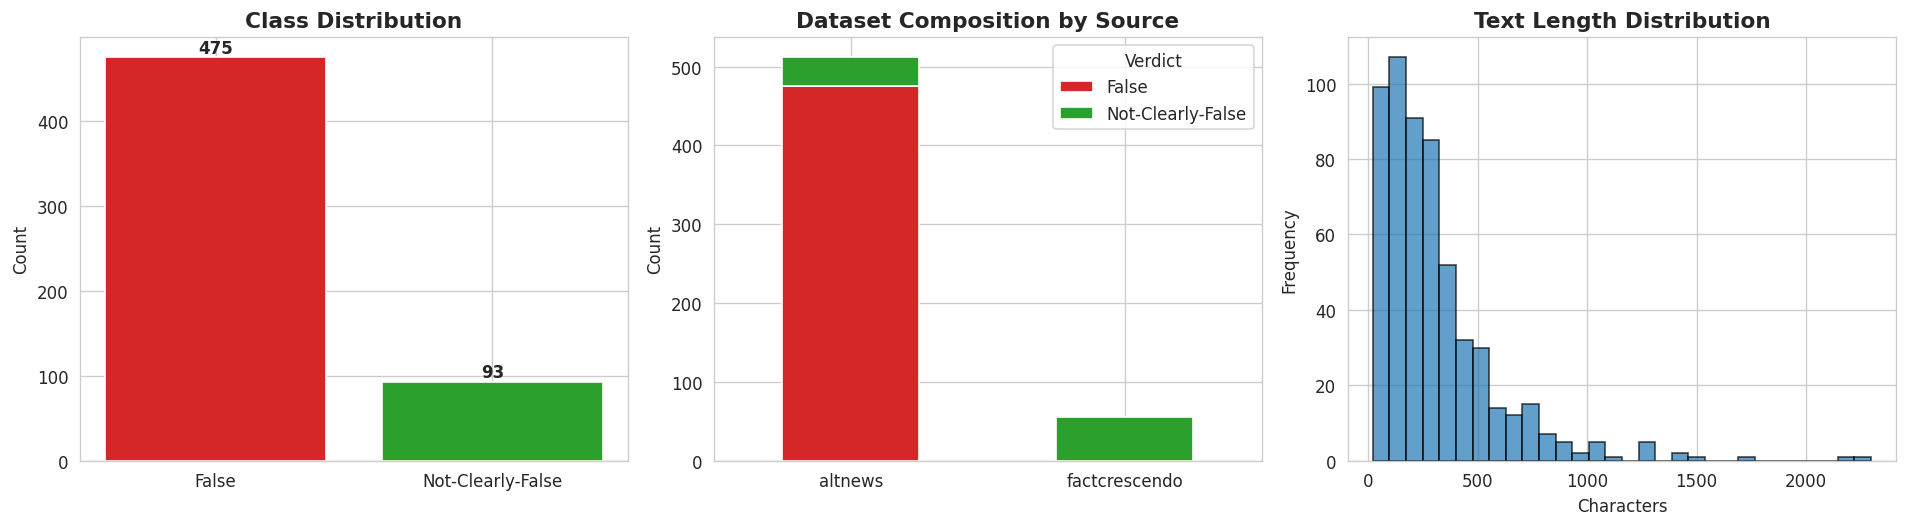

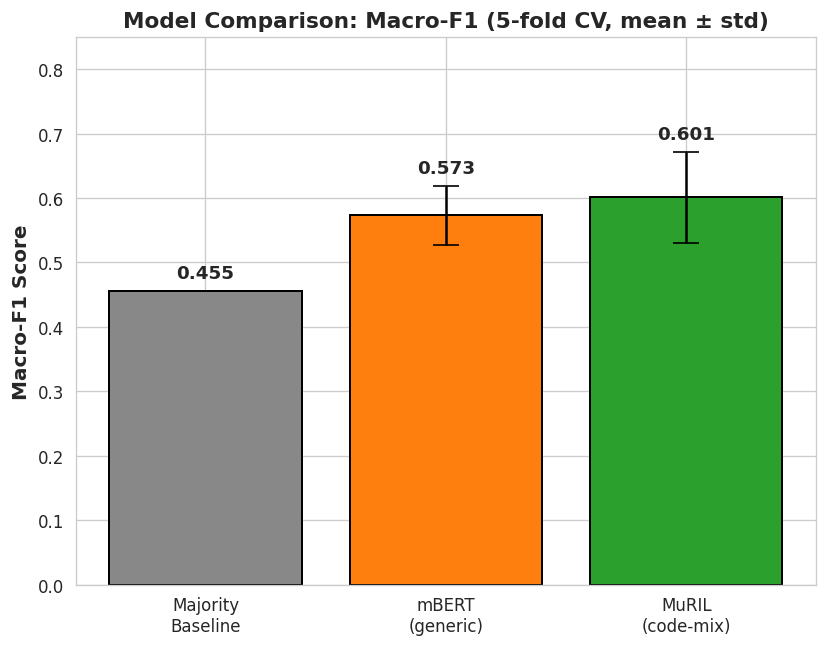

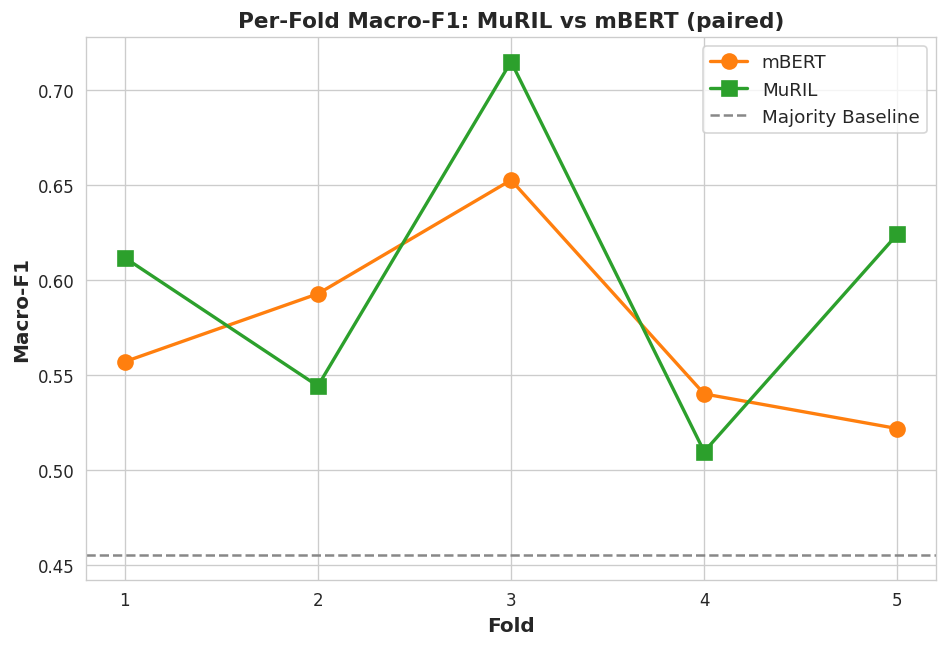

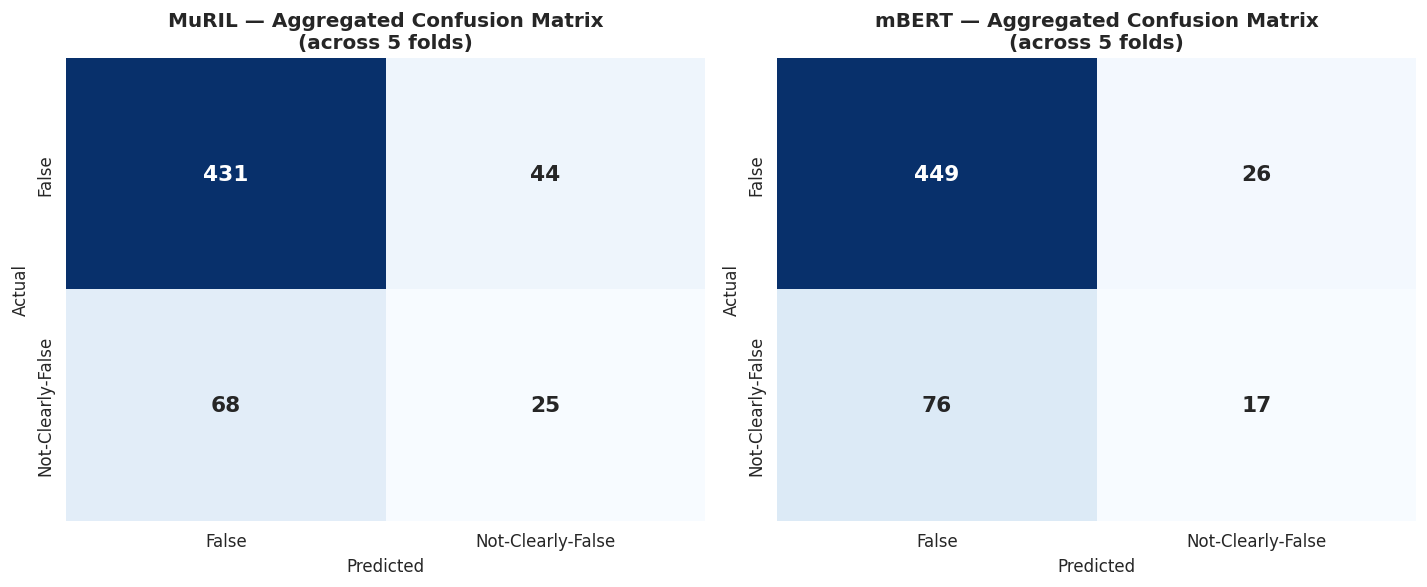

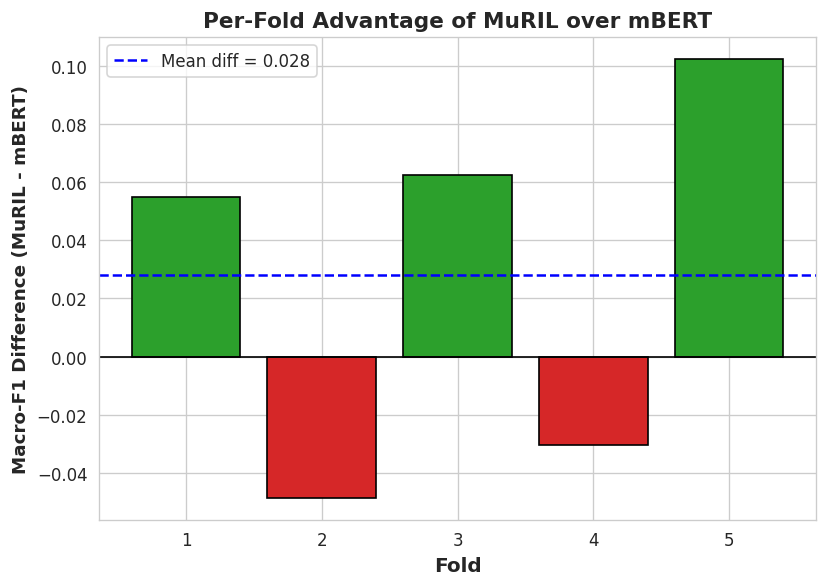


All figures saved to /content/drive/MyDrive/hinglish_misinfo_project/figures
Files: ['01_dataset_overview.png', '02_macro_f1_comparison.png', '03_per_fold_comparison.png', '04_confusion_matrices.png', '05_muril_advantage_per_fold.png']


In [ ]:

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

PROJECT_DIR = "/content/drive/MyDrive/hinglish_misinfo_project"
FIG_DIR = f"{PROJECT_DIR}/figures"
import os
os.makedirs(FIG_DIR, exist_ok=True)

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 120

# ---------------------------------------------------------------------
# 1. Save raw results to Drive
# ---------------------------------------------------------------------

def save_fold_results(fold_results, filename):
    out = []
    for r in fold_results:
        out.append({
            'fold': r['fold'],
            'macro_f1': float(r['macro_f1']),
            'preds': [int(p) for p in r['preds']],
            'true': [int(t) for t in r['true']],
        })
    with open(f"{PROJECT_DIR}/{filename}", 'w') as f:
        json.dump(out, f, indent=2)
    print(f"Saved {filename}")

save_fold_results(fold_results, "muril_kfold_results.json")
save_fold_results(fold_results_baseline, "mbert_kfold_results.json")

majority_f1s = [0.4554] * 5  # from earlier computation; replace with actual list if available

comparison_df = pd.DataFrame({
    'fold': [1,2,3,4,5],
    'majority_baseline': majority_f1s,
    'mbert': baseline_f1_scores,
    'muril': macro_f1_scores,
})
comparison_df.to_csv(f"{PROJECT_DIR}/model_comparison_results.csv", index=False)
print("Saved model_comparison_results.csv")
print(comparison_df)


# ---------------------------------------------------------------------
# 2. Dataset composition plots
# ---------------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Class distribution
label_counts = df['binary_label'].value_counts()
axes[0].bar(label_counts.index, label_counts.values, color=['#d62728', '#2ca02c'])
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Source breakdown
source_label = df.groupby(['source', 'binary_label']).size().unstack(fill_value=0)
source_label.plot(kind='bar', stacked=True, ax=axes[1], color=['#d62728', '#2ca02c'])
axes[1].set_title('Dataset Composition by Source', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].set_xlabel('')
axes[1].legend(title='Verdict')
axes[1].tick_params(axis='x', rotation=0)

# Text length distribution
axes[2].hist(df['text'].str.len(), bins=30, color='#1f77b4', edgecolor='black', alpha=0.7)
axes[2].set_title('Text Length Distribution', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Characters')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/01_dataset_overview.png", bbox_inches='tight')
plt.show()


# ---------------------------------------------------------------------
# 3. Macro-F1 comparison bar chart with error bars
# ---------------------------------------------------------------------

models = ['Majority\nBaseline', 'mBERT\n(generic)', 'MuRIL\n(code-mix)']
means = [np.mean(majority_f1s), np.mean(baseline_f1_scores), np.mean(macro_f1_scores)]
stds = [np.std(majority_f1s), np.std(baseline_f1_scores), np.std(macro_f1_scores)]
colors = ['#888888', '#ff7f0e', '#2ca02c']

fig, ax = plt.subplots(figsize=(7, 5.5))
bars = ax.bar(models, means, yerr=stds, capsize=8, color=colors, edgecolor='black', linewidth=1.2)
ax.set_ylabel('Macro-F1 Score', fontsize=12, fontweight='bold')
ax.set_title('Model Comparison: Macro-F1 (5-fold CV, mean ± std)', fontsize=13, fontweight='bold')
ax.set_ylim(0, 0.85)
for bar, mean, std in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width()/2, mean + std + 0.02,
            f'{mean:.3f}', ha='center', fontweight='bold', fontsize=11)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/02_macro_f1_comparison.png", bbox_inches='tight')
plt.show()


# ---------------------------------------------------------------------
# 4. Per-fold paired comparison plot
# ---------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 5.5))
folds = np.arange(1, 6)
ax.plot(folds, baseline_f1_scores, 'o-', label='mBERT', color='#ff7f0e', linewidth=2, markersize=9)
ax.plot(folds, macro_f1_scores, 's-', label='MuRIL', color='#2ca02c', linewidth=2, markersize=9)
ax.axhline(np.mean(majority_f1s), linestyle='--', color='#888888', label='Majority Baseline', linewidth=1.5)
ax.set_xlabel('Fold', fontsize=12, fontweight='bold')
ax.set_ylabel('Macro-F1', fontsize=12, fontweight='bold')
ax.set_title('Per-Fold Macro-F1: MuRIL vs mBERT (paired)', fontsize=13, fontweight='bold')
ax.set_xticks(folds)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/03_per_fold_comparison.png", bbox_inches='tight')
plt.show()


# ---------------------------------------------------------------------
# 5. Aggregated confusion matrices
# ---------------------------------------------------------------------

def aggregate_confusion(fold_results):
    all_true, all_preds = [], []
    for r in fold_results:
        all_true.extend(r['true'])
        all_preds.extend(r['preds'])
    return confusion_matrix(all_true, all_preds, labels=[0, 1])

cm_muril = aggregate_confusion(fold_results)
cm_mbert = aggregate_confusion(fold_results_baseline)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
labels_display = ['False', 'Not-Clearly-False']

for ax, cm, title in zip(axes, [cm_muril, cm_mbert], ['MuRIL', 'mBERT']):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=labels_display, yticklabels=labels_display,
                cbar=False, annot_kws={'fontsize': 13, 'fontweight': 'bold'})
    ax.set_title(f'{title} — Aggregated Confusion Matrix\n(across 5 folds)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/04_confusion_matrices.png", bbox_inches='tight')
plt.show()


# ---------------------------------------------------------------------
# 6. Per-fold difference plot (MuRIL - mBERT)
# ---------------------------------------------------------------------

diffs = np.array(macro_f1_scores) - np.array(baseline_f1_scores)
fig, ax = plt.subplots(figsize=(7, 5))
colors_diff = ['#2ca02c' if d > 0 else '#d62728' for d in diffs]
ax.bar(folds, diffs, color=colors_diff, edgecolor='black')
ax.axhline(0, color='black', linewidth=1)
ax.axhline(diffs.mean(), linestyle='--', color='blue', label=f'Mean diff = {diffs.mean():.3f}')
ax.set_xlabel('Fold', fontsize=12, fontweight='bold')
ax.set_ylabel('Macro-F1 Difference (MuRIL - mBERT)', fontsize=11, fontweight='bold')
ax.set_title('Per-Fold Advantage of MuRIL over mBERT', fontsize=13, fontweight='bold')
ax.set_xticks(folds)
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/05_muril_advantage_per_fold.png", bbox_inches='tight')
plt.show()

print(f"\nAll figures saved to {FIG_DIR}")
print("Files:", os.listdir(FIG_DIR))